# Barrow liquid-containing cloud susceptibility to LWP and duration thresholds

**Source:** DOE ARM observations at Utqiagvik (Barrow), NSA site, supplied by
Genie Lorenzo Pearson. Eleven cold seasons, 2014/15 through 2024/25,
Oct 1 - Mar 31.

Genie's phase classification is finer than anything ERA5 supports, because it
is built from the ARM radar/lidar/MWR suite. Three of her categories sum to
**liquid-containing**:

| category | meaning |
|---|---|
| `liq_only` | liquid only for the whole cloud episode |
| `liq_mixed` | episode contains both liquid-only and mixed-phase periods |
| `mixed_only` | mixed-phase only |

## Two interchangeable data sources

Set by `--source` on the command line, by `$GENIE_DATA_SOURCE`, or by editing
the default in `resolve_data_source`:

| `--source` | meaning |
|---|---|
| **`data`** (default) | Genie's own CSV exports, behind `LWP_CloudLengths_Thresholds_20142015to20242025.pptx` |
| `digitized_plot` | read off the rendered PNGs of the same figures, pixel by pixel |

Both paths return the same structure, so every figure below works either way,
and section 8 loads both at once and differences them. They agree: the LWP
sweep matches to 0.15% in absolute hours, and the retained-fraction curves
that carry every conclusion here never differ by more than 0.73 percentage
points -- worst at a 90-min threshold, where only 17% of the record is left
either way.

The seasonal bar chart is the one exception -- no CSV in the set carries the
three-category split by season, so that panel stays digitized under both
settings. It is used only for validation, never for a plotted result.

One place `digitized_plot` is genuinely the better source: its cloud-duration
bins are 1 min wide over 0-50 min, against 5 min in the CSV. The distribution
is steepest in exactly that range, so below a 5-min threshold the `data` curve
is a straight line across the first bin while the digitized one resolves the
real curvature. Above 5 min the CSV is better -- it is exact, and it runs to
400 min. If a threshold under 5 min matters, read it off `digitized_plot`.

## Three things to know before reading the numbers

**(a) The duration figures are histograms, not threshold curves.**
Genie's x-axis is "Cloud Length (minutes)" and the bar height is the hours per
season *contributed by clouds of that length*. It is a distribution. The
threshold curve wanted here -- hours retained when clouds shorter than tau are
discarded -- is the **reverse cumulative sum** of that distribution, computed
in `exceedance_from_histogram` below. Reading the first bar of the histogram as
"the value at threshold 0" would be wrong by a factor of three.

**(b) The two curves do not share a baseline.**
The LWP curve at its own 2 g m-2 point gives 1375 h/season. The cloud-length
histogram, from the same 11 seasons, integrates to 1559 h/season -- 13.4%
higher. The duration analysis bridges clear gaps shorter than 90 s, absorbing
those minutes into the cloud episode and counting them as cloud time. So the
two curves are compared by *shape* (fraction retained), not by absolute height.
Section 6 normalizes the offset away; section 5 draws it explicitly.

**(c) The LWP threshold column runs from -10 g m-2, not 0.**
Negative thresholds are not a mistake. MWR liquid water path retrievals carry
noise of a few g m-2 and go negative in genuinely clear scenes, so a -10 g m-2
threshold keeps essentially the whole record. The rows below 0 are the noise
floor, and they are worth 92.6 h/season -- 6.4% of the LWP > 0 total. That is
the size of the penalty for not thresholding at all.

In [1]:
from __future__ import annotations

import argparse
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

VALID_SOURCES = ("data", "digitized_plot")

DEFAULT_CSV_DIR = Path(
    "/Users/andrewbuggee/Documents/Scripps - UCSD/Ocean Visions/Genie Lorenzo Pearson"
)


def resolve_data_source(default: str = "data") -> tuple[str, Path]:
    """Resolve the data source and CSV directory from CLI, environment, defaults.

    Precedence: ``--source`` / ``--csv-dir`` on the command line, then
    ``$GENIE_DATA_SOURCE`` / ``$GENIE_CSV_DIR``, then the defaults. Uses
    ``parse_known_args`` so the Jupyter kernel's own argv (``-f kernel.json``)
    is ignored rather than raising.
    """
    parser = argparse.ArgumentParser(add_help=False)
    parser.add_argument("--source", choices=VALID_SOURCES, default=None)
    parser.add_argument("--csv-dir", default=None)
    args, _ = parser.parse_known_args()

    source = args.source or os.environ.get("GENIE_DATA_SOURCE") or default
    if source not in VALID_SOURCES:
        raise ValueError(f"source must be one of {VALID_SOURCES}, got {source!r}")

    csv_dir = Path(args.csv_dir or os.environ.get("GENIE_CSV_DIR") or DEFAULT_CSV_DIR)
    return source, csv_dir


DATA_SOURCE, CSV_DIR = resolve_data_source()

# Genie's 30-s sampling and the 11-season record length. Both conversions are
# hers: "divide by 120 to convert to hour, and ... divided by 11 to get the
# Hours per Season".
SAMPLES_PER_HOUR_30S = 120.0     # 30-s samples in an hour
MINUTES_PER_HOUR = 60.0
N_SEASONS = 11

# The synthesis figures are drawn over this LWP range regardless of source, so
# the two sources stay directly comparable. The `data` source carries thresholds
# down to -10 g m-2; the QC panel in section 3 shows the full range.
LWP_PLOT_RANGE_GM2 = (0.0, 20.0)
DUR_AXIS_MAX_MIN = 60

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12.5,
        "axes.linewidth": 1.1,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.frameon": True,
        "legend.framealpha": 0.92,
        "legend.edgecolor": "0.75",
    }
)

# Category colours. Genie's mapping (red / yellow / green) is kept recognisable
# but darkened -- pure yellow is unreadable as a line on white.
C_LIQ = "#C62828"   # liquid only
C_MIX = "#E8A33D"   # liquid + mixed
C_MXO = "#2E7D32"   # mixed only
CATS = ("liq_only", "liq_mixed", "mixed_only")
CAT_LABELS = ("liquid only", "liquid + mixed", "mixed only")
CAT_COLORS = (C_LIQ, C_MIX, C_MXO)

# Curve colours for the synthesis figures
C_LWP = "black"
C_DUR = "#0072B2"   # colourblind-safe blue

print(f"DATA_SOURCE = {DATA_SOURCE!r}")
print(f"CSV_DIR     = {CSV_DIR}")

DATA_SOURCE = 'data'
CSV_DIR     = /Users/andrewbuggee/Documents/Scripps - UCSD/Ocean Visions/Genie Lorenzo Pearson


## 1. The two loaders

### 1a. `data` -- Genie's CSV exports

Five files, and the conventions in them are not self-describing. What each one
holds, and how it was pinned down:

**`LWPthresholds.csv`** -- a pandas export: an unnamed index 0..30 and one data
column holding **-10 .. 20**. Genie's "the LWP threshold is the first column"
means that data column, not the index. Confirmed numerically: the threshold-2
row of `liquidonly.csv` gives 436.5 h/season, which is the 437 h printed in her
seasonal figure's legend, whereas the index-2 row would give 542 h.

**`liquidonly.csv`, `liqmix.csv`, `mixedonly.csv`** -- 31 rows each, aligned to
the 31 thresholds, in counts of 30-s samples over the whole record. Hours per
season = counts / 120 / 11. All three reproduce the figure legend at 2 g m-2
(437 / 789 / 149) to a tenth of an hour.

**`cloudlengths_5mins_bins.csv`** -- 81 bin edges, 0 to 400 min, 5 min wide,
so 80 bins.

**`cloudlengths_5mins.csv`** -- 3 rows x 80 bins, and these are **cumulative
stack levels, not independent categories**. Row 1 <= row 2 <= row 3 holds in
every one of the 80 bins, and de-stacking gives no negative value anywhere:

* row 1 = `liq_only`
* row 2 - row 1 = `liq_mixed`
* row 3 - row 2 = `mixed_only`

Taking the rows as independent categories instead would make `mixed_only` come
out as -227 029 counts.

The unit here is minutes, not 30-s samples -- Genie's "the cloud lengths data
is in counts per minutes". Hours per season = counts / 60 / 11. The
half-integer values (68954.5) are 30-s data expressed in minutes. The factor of
2 is not a judgement call: reading these as 30-s counts would put the total at
779 h/season, which is *below* the 1375 h that survives an LWP > 2 cut of the
same record, and a gap-bridged duration analysis cannot lose hours.

In [2]:
def exceedance_from_histogram(
    edges_min: np.ndarray, hours_by_bin: dict[str, np.ndarray]
) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    """Reverse cumulative sum of a cloud-duration histogram.

    ``H(tau) = sum of hours over all bins at or beyond tau``, evaluated at each
    bin's left edge. This is the hours per season retained by a minimum cloud
    duration threshold.
    """
    tau_min = edges_min[:-1]
    retained = {
        cat: np.array([v[k:].sum() for k in range(v.size)])
        for cat, v in hours_by_bin.items()
    }
    return tau_min, retained


def load_genie_csv(csv_dir: Path = CSV_DIR) -> dict:
    """Load Genie's CSV exports into the common structure used below.

    Returns the LWP threshold sweep, the cloud-duration histogram, and the
    cloud-duration exceedance curve derived from it.
    """
    lwp_threshold_gm2 = (
        pd.read_csv(csv_dir / "LWPthresholds.csv", index_col=0).iloc[:, 0].to_numpy(float)
    )

    counts_file = {
        "liq_only": "liquidonly.csv",
        "liq_mixed": "liqmix.csv",
        "mixed_only": "mixedonly.csv",
    }
    lwp_hours = {}
    for cat, fname in counts_file.items():
        counts_30s = pd.read_csv(csv_dir / fname, index_col=0).iloc[:, 0].to_numpy(float)
        if counts_30s.size != lwp_threshold_gm2.size:
            raise ValueError(
                f"{fname}: {counts_30s.size} rows vs {lwp_threshold_gm2.size} thresholds"
            )
        lwp_hours[cat] = counts_30s / SAMPLES_PER_HOUR_30S / N_SEASONS

    # --- cloud-duration histogram -----------------------------------------
    edges_min = (
        pd.read_csv(csv_dir / "cloudlengths_5mins_bins.csv").iloc[:, 0].to_numpy(float)
    )
    stacked_min = pd.read_csv(csv_dir / "cloudlengths_5mins.csv").to_numpy(float)
    if stacked_min.shape != (3, edges_min.size - 1):
        raise ValueError(
            f"cloudlengths_5mins.csv is {stacked_min.shape}, expected "
            f"{(3, edges_min.size - 1)}"
        )
    if not np.all(np.diff(stacked_min, axis=0) >= 0):
        raise ValueError(
            "cloud-duration rows are not nested; the cumulative-stack reading of "
            "this file is wrong"
        )

    per_bin_min = np.vstack([stacked_min[0], np.diff(stacked_min, axis=0)])
    cloud_duration_hours = {
        cat: per_bin_min[i] / MINUTES_PER_HOUR / N_SEASONS for i, cat in enumerate(CATS)
    }

    tau_min, duration_hours = exceedance_from_histogram(edges_min, cloud_duration_hours)
    return {
        "source": "data",
        "lwp_threshold_gm2": lwp_threshold_gm2,
        "lwp_hours": lwp_hours,
        "hist_edges_min": edges_min,
        "hist_hours": cloud_duration_hours,
        "duration_threshold_min": tau_min,
        "duration_hours": duration_hours,
    }

### 1b. `digitized_plot` -- read off the rendered PNGs

Every array below was read off the PNG by locating the axes frame and the tick
marks in pixel space, then reading the top edge of each stacked segment.
Pixel-to-data scales:

| figure | y = 0 at row | scale |
|---|---|---|
| seasonal bars | 526 | 2000 h / 511 px |
| LWP curves | 666 | 900 h / 643 px |
| duration, 10-min bins | 511 | 500 h / 475 px |
| duration, 1-min bins | 513 | 14.286 h / 94 px |

One subtlety worth recording: in the seasonal figure the last bar (2024/25)
runs up **behind the legend box**, whose face is white at alpha 0.8. Its
`mixed_only` cap therefore renders as (203, 229, 203) rather than (0, 128, 0),
and a naive colour match drops it, pulling the eleven-season `mixed_only` mean
from 149 h down to 137 h. The alpha-blended colour was matched explicitly.

In [3]:
# ---------------------------------------------------------------------------
# Total hours per season, 2014/15 - 2024/25. Digitized under both settings --
# no CSV in the set carries this split. Seasons are labelled by START year,
# matching ERA5/surface_energy_budget/genie_arm_seasonal_hours.txt.
# LWP cutoff 2 g m-2, no duration cutoff.
# ---------------------------------------------------------------------------
season_start_year = np.arange(2014, 2025)

seasonal_hours = {
    "liq_only": np.array(
        [344.4, 692.8, 454.0, 465.8, 399.2, 399.2, 274.0, 418.8, 407.0, 360.1, 571.4]
    ),
    "liq_mixed": np.array(
        [771.0, 1005.9, 692.8, 688.8, 673.2, 798.4, 371.8, 821.9, 978.5, 896.3, 978.5]
    ),
    "mixed_only": np.array(
        [129.2, 137.0, 184.0, 211.4, 109.6, 93.9, 97.8, 156.6, 187.9, 180.0, 148.7]
    ),
}

# Totals printed in the legends of Genie's own figures. Used as ground truth.
LEGEND_SEASONAL_MEAN = {"liq_only": 437.0, "liq_mixed": 789.0, "mixed_only": 149.0}
LEGEND_DURATION_TOTAL = {"liq_only": 488.0, "liq_mixed": 860.0, "mixed_only": 165.0}


def load_digitized_plot() -> dict:
    """Digitized contents of the two threshold figures, in the common structure.

    The cloud-duration histogram was digitized twice, at 1-min resolution over
    0-50 min and at 10-min resolution out to 410 min. Both are used: the fine
    bins where the distribution is steep, the coarse ones for the tail. Each
    category is then scaled by a single constant so its integral matches the
    figure legend, which removes the systematic half-pixel low bias of reading
    41 bar tops in the same direction.
    """
    lwp_threshold_gm2 = np.arange(0, 21, dtype=float)
    lwp_hours = {
        "liq_only": np.array(
            [474.5, 455.6, 437.4, 417.8, 399.6, 382.1, 366.0, 350.6, 333.8, 319.8,
             307.2, 294.6, 284.1, 273.6, 265.2, 255.4, 244.9, 237.9, 228.8, 221.9,
             213.5]
        ),
        "liq_mixed": np.array(
            [813.2, 802.0, 790.1, 777.5, 764.2, 750.2, 737.6, 727.1, 715.2, 704.0,
             692.8, 684.4, 673.3, 664.9, 656.5, 646.7, 638.3, 629.2, 622.2, 613.1,
             606.1]
        ),
        "mixed_only": np.array(
            [163.1, 156.1, 149.1, 142.1, 135.1, 128.1, 122.5, 116.9, 112.0, 108.5,
             102.9, 101.5, 97.3, 93.8, 92.4, 88.9, 86.8, 85.4, 83.3, 81.2, 81.2]
        ),
    }

    edges_1min = np.arange(0, 51, dtype=float)          # 50 bins, 1 min wide
    edges_10min = np.arange(0, 411, 10, dtype=float)    # 41 bins, 10 min wide

    hist_1min = {
        "liq_only": np.array([
            11.70, 24.16, 23.56, 20.82, 18.84, 16.72, 15.35, 13.68,
            12.77, 11.09, 10.03, 10.03,  9.42,  8.36,  7.45,  7.29,
             7.14,  6.99,  6.84,  6.23,  5.93,  5.78,  4.86,  5.32,
             5.17,  4.56,  4.56,  4.41,  4.71,  4.10,  4.41,  3.19,
             3.34,  3.95,  3.19,  3.19,  3.19,  2.89,  3.19,  2.43,
             2.89,  2.74,  2.43,  3.19,  2.28,  2.58,  2.58,  3.65,
             1.98,  3.04,
        ]),
        "liq_mixed": np.array([
            13.07, 32.67, 31.31, 30.24, 26.90, 25.38, 23.10, 20.52,
            20.21, 17.78, 16.72, 15.96, 14.44, 14.44, 13.22, 12.46,
            11.25, 11.25, 11.40,  9.73,  9.12,  9.42,  9.27,  8.97,
             7.45,  6.99,  7.75,  7.75,  6.53,  6.08,  6.38,  6.23,
             5.62,  5.93,  5.17,  6.08,  5.02,  5.02,  5.02,  5.78,
             5.02,  5.17,  5.02,  4.10,  5.17,  4.41,  4.71,  4.41,
             4.86,  6.08,
        ]),
        "mixed_only": np.array([
             8.81, 16.11, 13.83, 12.01, 10.18,  8.21,  7.45,  6.69,
             5.93,  5.32,  5.02,  3.95,  3.19,  3.19,  3.34,  2.74,
             2.74,  2.89,  2.28,  2.28,  1.67,  1.52,  2.28,  1.82,
             1.22,  1.22,  1.37,  1.52,  1.52,  0.76,  1.06,  0.76,
             0.91,  0.76,  1.22,  0.91,  0.91,  0.76,  1.06,  0.30,
             0.46,  0.91,  0.76,  0.61,  0.76,  0.91,  0.46,  0.46,
             0.15,  0.46,
        ]),
    }
    hist_10min = {
        "liq_only": np.array([
            167.37, 77.89, 48.42, 30.53, 25.26, 21.05, 16.84, 12.63,
             10.53,  7.37,  9.47,  7.37,  5.26,  5.26,  3.16,  3.16,
              3.16,  2.11,  3.16,  1.05,  3.16,  1.05,  0.00,  1.05,
              1.05,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,
              1.05,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,
              0.00,
        ]),
        "liq_mixed": np.array([
            242.11, 131.58, 80.00, 57.89, 47.37, 32.63, 27.37, 22.11,
             20.00,  16.84, 13.68, 15.79, 11.58, 11.58,  8.42, 10.53,
              4.21,   8.42,  6.32,  5.26,  4.21,  4.21,  4.21,  5.26,
              3.16,   3.16,  2.11,  5.26,  3.16,  3.16,  3.16,  3.16,
              2.11,   3.16,  2.11,  1.05,  2.11,  4.21,  1.05,  1.05,
              0.00,
        ]),
        "mixed_only": np.array([
            94.74, 31.58, 13.68,  8.42,  6.32,  3.16,  3.16,  2.11,
             2.11,  2.11,  0.00,  1.05,  0.00,  0.00,  1.05,  0.00,
             2.11,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  1.05,
             0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,
             0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,
             0.00,
        ]),
    }

    # Calibrate each category to its own legend integral, then splice:
    #   0-50 min  from the 1-min bins   (fine structure where it matters)
    #   50 min +  from the 10-min bins  (the tail)
    raw_total = {c: hist_1min[c].sum() + hist_10min[c][5:].sum() for c in CATS}
    cal = {c: LEGEND_DURATION_TOTAL[c] / raw_total[c] for c in CATS}
    hist_1min_cal = {c: hist_1min[c] * cal[c] for c in CATS}
    hist_10min_cal = {c: hist_10min[c] * cal[c] for c in CATS}

    tau_fine_min = np.arange(0, 51, dtype=float)
    tau_coarse_min = np.arange(60, 410, 10, dtype=float)
    tau_min = np.concatenate([tau_fine_min, tau_coarse_min])
    duration_hours = {}
    for c in CATS:
        tail_h = hist_10min_cal[c][5:].sum()
        fine = np.array([hist_1min_cal[c][int(t):].sum() + tail_h for t in tau_fine_min])
        coarse = np.array([hist_10min_cal[c][int(t) // 10:].sum() for t in tau_coarse_min])
        duration_hours[c] = np.concatenate([fine, coarse])

    return {
        "source": "digitized_plot",
        "lwp_threshold_gm2": lwp_threshold_gm2,
        "lwp_hours": lwp_hours,
        "hist_edges_min": edges_1min,          # the 1-min view, for the QC panel
        "hist_hours": hist_1min_cal,
        "duration_threshold_min": tau_min,
        "duration_hours": duration_hours,
        "_raw_total": raw_total,
        "_calibration": cal,
        "_edges_10min": edges_10min,
    }

## 2. Load, and validate

Checks, none of which was used to set any scale factor:

1. The eleven-season mean of the digitized seasonal bars must equal the
   seasonal figure's own legend (437 / 789 / 149 h).
2. The active source's LWP curve evaluated at **2 g m-2** must equal that same
   seasonal mean, because the seasonal figure was built with a 2 g m-2 cutoff.
   Two separate figures, so this is a real cross-check.
3. The cloud-duration histogram's integral, against the duration figure's
   legend (488 / 860 / 165 h).

In [4]:
LOADERS = {"data": load_genie_csv, "digitized_plot": load_digitized_plot}
ds = LOADERS[DATA_SOURCE]()

lwp_threshold_gm2 = ds["lwp_threshold_gm2"]
lwp_hours = ds["lwp_hours"]
duration_threshold_min = ds["duration_threshold_min"]
duration_hours = ds["duration_hours"]

lwp_total_h = sum(lwp_hours[c] for c in CATS)
duration_total_h = sum(duration_hours[c] for c in CATS)


def at_lwp(hours: np.ndarray, threshold_gm2: float) -> float:
    """Value of an LWP-swept quantity at one threshold. Exact, not interpolated."""
    idx = np.flatnonzero(np.isclose(lwp_threshold_gm2, threshold_gm2))
    if idx.size != 1:
        raise ValueError(f"threshold {threshold_gm2} g m-2 not present in the sweep")
    return float(hours[idx[0]])


def at_duration(hours: np.ndarray, threshold_min: float) -> float:
    """Value of a duration-swept quantity at one threshold. Exact, not interpolated."""
    idx = np.flatnonzero(np.isclose(duration_threshold_min, threshold_min))
    if idx.size != 1:
        raise ValueError(f"threshold {threshold_min} min not present in the sweep")
    return float(hours[idx[0]])


def _row(label: str, got: dict[str, float], want: dict[str, float]) -> None:
    """Print one validation row: value, reference value, % error."""
    parts = []
    for c in CATS:
        err = 100.0 * (got[c] - want[c]) / want[c]
        parts.append(f"{got[c]:7.1f} vs {want[c]:6.1f} ({err:+5.2f}%)")
    print(f"  {label:<36s} " + " | ".join(parts))


print(f"source = {DATA_SOURCE!r}")
print(f"LWP sweep: {lwp_threshold_gm2.min():.0f} .. {lwp_threshold_gm2.max():.0f} g m-2 "
      f"({lwp_threshold_gm2.size} steps)")
print(f"cloud-duration bins: {ds['hist_edges_min'][0]:.0f} .. "
      f"{ds['hist_edges_min'][-1]:.0f} min, "
      f"{np.diff(ds['hist_edges_min'])[0]:.0f} min wide")
print()
print("categories:                          " + " | ".join(f"{c:^24s}" for c in CATS))
print()
_row("1. seasonal bars, 11-season mean",
     {c: float(seasonal_hours[c].mean()) for c in CATS}, LEGEND_SEASONAL_MEAN)
_row("2. LWP curve at 2 g m-2",
     {c: at_lwp(lwp_hours[c], 2.0) for c in CATS}, LEGEND_SEASONAL_MEAN)
_row("3. cloud-duration histogram integral",
     {c: float(ds["hist_hours"][c].sum()) if DATA_SOURCE == "data"
      else float(ds["_raw_total"][c]) for c in CATS}, LEGEND_DURATION_TOTAL)

if DATA_SOURCE == "digitized_plot":
    print()
    print("  calibration applied to the digitized histogram:",
          {c: round(ds["_calibration"][c], 4) for c in CATS})

source = 'data'
LWP sweep: -10 .. 20 g m-2 (31 steps)
cloud-duration bins: 0 .. 400 min, 5 min wide

categories:                                  liq_only         |        liq_mixed         |        mixed_only       

  1. seasonal bars, 11-season mean       435.2 vs  437.0 (-0.42%) |   788.8 vs  789.0 (-0.02%) |   148.7 vs  149.0 (-0.18%)
  2. LWP curve at 2 g m-2                436.5 vs  437.0 (-0.11%) |   789.5 vs  789.0 (+0.06%) |   149.1 vs  149.0 (+0.08%)
  3. cloud-duration histogram integral   524.0 vs  488.0 (+7.37%) |   855.0 vs  860.0 (-0.58%) |   180.0 vs  165.0 (+9.07%)


Check 2 is the strong one. Under `data` it holds to a tenth of an hour out of
437, and that is what pins down the reading of `LWPthresholds.csv`. Under
`digitized_plot` it holds to 0.1%, from two separate PNGs with separate pixel
calibrations -- digitization is not the limiting source of error anywhere
downstream.

Check 3 is the one with a real residual under `data`: the CSV integrates to
524 / 855 / 180 h against a legend of 488 / 860 / 165. `liq_mixed` agrees to
0.6%, but `liq_only` comes out 7.4% high and `mixed_only` 9.1% high, and the
disagreement is not a common factor, so it is not a units error. Worth asking
Genie about. It does not affect anything below, which all runs on retained
*fractions*, and no calibration is applied to the CSV.

In [5]:
# The sub-zero LWP rows are the MWR noise floor. Only the `data` source has them.
if (lwp_threshold_gm2 < 0).any():
    ref_h = at_lwp(lwp_total_h, 0.0)
    print("MWR noise floor -- liquid-containing hours per season below LWP = 0:\n")
    print("  LWP thr    hours    excess over LWP > 0")
    for t in (-10.0, -5.0, -2.0, -1.0, 0.0):
        v = at_lwp(lwp_total_h, t)
        print(f"  {t:6.0f} {v:9.1f} {v - ref_h:+15.1f} h  ({100 * (v - ref_h) / ref_h:+.1f}%)")
    print("\n  Thresholding at 0 rather than -10 g m-2 discards "
          f"{at_lwp(lwp_total_h, -10.0) - ref_h:.1f} h/season of retrieval noise.")
else:
    print("source 'digitized_plot' has no sub-zero LWP thresholds "
          "(Genie's figure starts at 0).")

MWR noise floor -- liquid-containing hours per season below LWP = 0:

  LWP thr    hours    excess over LWP > 0
     -10    1542.2           +92.6 h  (+6.4%)
      -5    1525.9           +76.3 h  (+5.3%)
      -2    1492.4           +42.7 h  (+2.9%)
      -1    1473.5           +23.8 h  (+1.6%)
       0    1449.6            +0.0 h  (+0.0%)

  Thresholding at 0 rather than -10 g m-2 discards 92.6 h/season of retrieval noise.


## 3. Reproduce Genie's figures

A visual check. If these panels do not look like the originals, something above
is wrong. Panel (b) shows the full LWP range the active source carries,
including the negative thresholds under `data`.

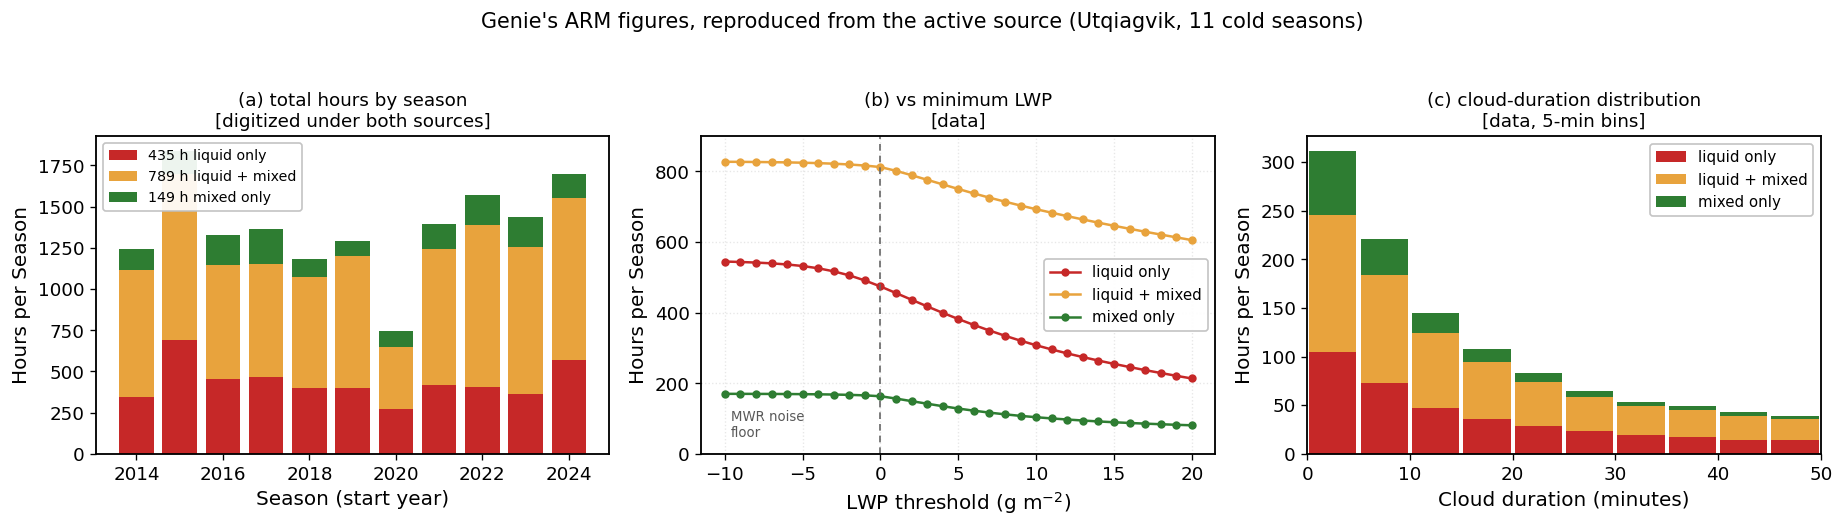

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))

# (a) seasonal stacked bars -- always digitized
ax = axes[0]
bottom = np.zeros_like(seasonal_hours["liq_only"])
for c, lab, col in zip(CATS, CAT_LABELS, CAT_COLORS):
    ax.bar(season_start_year, seasonal_hours[c], bottom=bottom, width=0.8,
           color=col, label=f"{seasonal_hours[c].mean():.0f} h {lab}")
    bottom += seasonal_hours[c]
ax.set_xlabel("Season (start year)")
ax.set_ylabel("Hours per Season")
ax.set_title("(a) total hours by season\n[digitized under both sources]", fontsize=11)
ax.legend(fontsize=8.5, loc="upper left")

# (b) LWP threshold curves
ax = axes[1]
for c, lab, col in zip(CATS, CAT_LABELS, CAT_COLORS):
    ax.plot(lwp_threshold_gm2, lwp_hours[c], "o-", ms=4, color=col, label=lab)
ax.set_xlabel(r"LWP threshold (g m$^{-2}$)")
ax.set_ylabel("Hours per Season")
ax.set_title(f"(b) vs minimum LWP\n[{DATA_SOURCE}]", fontsize=11)
ax.set_ylim(0, 900)
ax.xaxis.set_major_locator(MultipleLocator(5))
if (lwp_threshold_gm2 < 0).any():
    ax.axvline(0.0, color="0.4", lw=1.0, ls=(0, (4, 3)))
    ax.annotate("MWR noise\nfloor", xy=(lwp_threshold_gm2.min() + 0.4, 40),
                fontsize=8, color="0.35", ha="left", va="bottom")
ax.grid(alpha=0.3, ls=":")
ax.legend(fontsize=9)

# (c) cloud-duration histogram
ax = axes[2]
edges = ds["hist_edges_min"]
widths = np.diff(edges)
centers = edges[:-1] + widths / 2
bottom = np.zeros_like(centers)
for c, lab, col in zip(CATS, CAT_LABELS, CAT_COLORS):
    ax.bar(centers, ds["hist_hours"][c], bottom=bottom, width=widths * 0.92,
           color=col, label=lab)
    bottom += ds["hist_hours"][c]
ax.set_xlabel("Cloud duration (minutes)")
ax.set_ylabel("Hours per Season")
ax.set_title(f"(c) cloud-duration distribution\n[{DATA_SOURCE}, "
             f"{widths[0]:.0f}-min bins]", fontsize=11)
ax.set_xlim(0, 50)
ax.legend(fontsize=9)

fig.suptitle("Genie's ARM figures, reproduced from the active source "
             "(Utqiagvik, 11 cold seasons)", y=1.04, fontsize=12.5)
fig.tight_layout()
plt.show()

## 4. The duration threshold curve

For a minimum-duration threshold $\tau$, the hours retained are

$$H(\tau) \;=\; \sum_{d \,\ge\, \tau} h(d)$$

where $h(d)$ is the cloud-duration histogram. This is a survival (exceedance)
curve: $H(0)$ is the full record and it falls monotonically.

In [7]:
print(f"[{DATA_SOURCE}]")
print(f"liquid-containing hours per season, no duration cut : {duration_total_h[0]:7.1f}")
print(f"liquid-containing hours per season, LWP > 2 g m-2   : "
      f"{at_lwp(lwp_total_h, 2.0):7.1f}")
print(f"ratio (90 s gap-bridging inflation)                 : "
      f"{duration_total_h[0] / at_lwp(lwp_total_h, 2.0):7.3f}")
print()
print(" tau (min)   liq_only  liq+mixed  mixed_only     TOTAL   % of tau=0")
for t in (0, 5, 10, 15, 20, 30, 45, 60, 90, 120, 180):
    if not np.isclose(duration_threshold_min, t).any():
        continue
    print(f"  {t:6d}   {at_duration(duration_hours['liq_only'], t):8.1f} "
          f"{at_duration(duration_hours['liq_mixed'], t):9.1f} "
          f"{at_duration(duration_hours['mixed_only'], t):10.1f} "
          f"{at_duration(duration_total_h, t):9.1f} "
          f"{100 * at_duration(duration_total_h, t) / duration_total_h[0]:9.1f}")

[data]
liquid-containing hours per season, no duration cut :  1558.9
liquid-containing hours per season, LWP > 2 g m-2   :  1375.1
ratio (90 s gap-bridging inflation)                 :   1.134

 tau (min)   liq_only  liq+mixed  mixed_only     TOTAL   % of tau=0
       0      524.0     855.0      180.0    1558.9     100.0
       5      419.5     713.9      114.6    1248.0      80.1
      10      346.6     603.0       77.9    1027.4      65.9
      15      299.0     525.9       57.7     882.6      56.6
      20      263.1     467.9       44.2     775.2      49.7
      30      211.3     387.8       28.7     627.8      40.3
      45      161.4     305.2       16.5     483.1      31.0
      60      125.0     249.7       10.0     384.7      24.7
      90       80.1     179.3        5.0     264.5      17.0
     120       51.4     132.5        2.0     185.8      11.9
     180       23.9      74.5        0.7      99.0       6.3


## 5. Figure 1 -- the two thresholds on shared axes

Hours per season on y, LWP threshold on the lower (black) axis, cloud-duration
threshold on the upper (blue) axis, each curve drawn in the colour of its own
axis.

The duration axis is cut at 60 min. Beyond that the curve is still falling but
only a quarter of the hours are left, and stretching the axis to 400 min
compresses everything that matters into the first eighth of the panel.

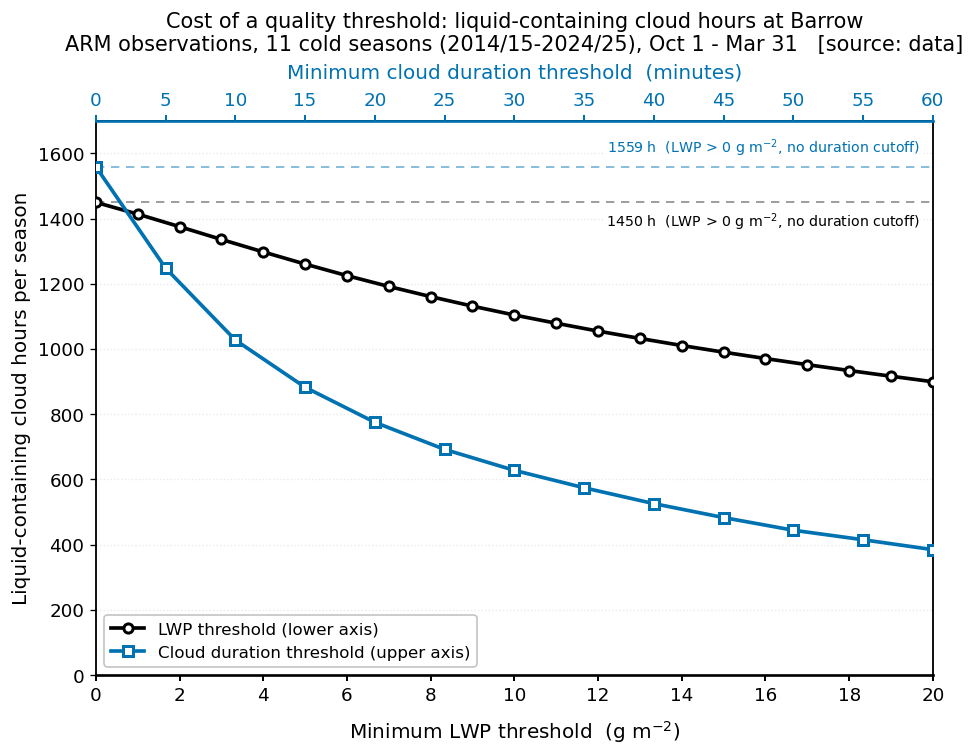

In [8]:
lwp_plot = ((lwp_threshold_gm2 >= LWP_PLOT_RANGE_GM2[0])
            & (lwp_threshold_gm2 <= LWP_PLOT_RANGE_GM2[1]))
dur_plot = duration_threshold_min <= DUR_AXIS_MAX_MIN


def marker_kwargs(n_points: int) -> dict:
    """Marker style that keeps ONE marker per data point legible at any density.

    The `data` source samples cloud duration every 5 min (13 points over
    0-60 min); `digitized_plot` samples it every 1 min (52 points over the same
    span). Both get a marker on every point -- the dense case just gets a
    smaller one so the markers stay separated rather than merging into a band.
    """
    if n_points <= 30:
        return dict(ms=5.5, mfc="white", mew=1.8)
    return dict(ms=3.5, mfc="white", mew=1.0)


lwp_mk = marker_kwargs(int(lwp_plot.sum()))
dur_mk = marker_kwargs(int(dur_plot.sum()))

fig, ax_lwp = plt.subplots(figsize=(9.0, 6.0))
ax_dur = ax_lwp.twiny()

# --- LWP curve, bottom axis, black -----------------------------------------
ax_lwp.plot(lwp_threshold_gm2[lwp_plot], lwp_total_h[lwp_plot], "o-", color=C_LWP,
            lw=2.2, zorder=4, label="LWP threshold (lower axis)", **lwp_mk)
ax_lwp.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)", color=C_LWP, labelpad=8)
ax_lwp.tick_params(axis="x", colors=C_LWP, width=1.2)
ax_lwp.set_xlim(*LWP_PLOT_RANGE_GM2)
ax_lwp.xaxis.set_major_locator(MultipleLocator(2))
ax_lwp.spines["bottom"].set_color(C_LWP)
ax_lwp.spines["bottom"].set_linewidth(1.6)

# --- duration curve, top axis, blue ----------------------------------------
ax_dur.plot(duration_threshold_min[dur_plot], duration_total_h[dur_plot], "s-",
            color=C_DUR, lw=2.2, zorder=4,
            label="Cloud duration threshold (upper axis)", **dur_mk)
ax_dur.set_xlabel("Minimum cloud duration threshold  (minutes)", color=C_DUR, labelpad=8)
ax_dur.tick_params(axis="x", colors=C_DUR, width=1.2)
ax_dur.set_xlim(0, DUR_AXIS_MAX_MIN)
ax_dur.xaxis.set_major_locator(MultipleLocator(5))
ax_dur.spines["top"].set_color(C_DUR)
ax_dur.spines["top"].set_linewidth(1.6)
for s in ("bottom", "left", "right"):
    ax_dur.spines[s].set_visible(False)

ax_lwp.set_ylabel("Liquid-containing cloud hours per season")
ax_lwp.set_ylim(0, 1700)
ax_lwp.yaxis.set_major_locator(MultipleLocator(200))
ax_lwp.grid(axis="y", alpha=0.28, ls=":", zorder=0)
ax_lwp.set_axisbelow(True)

# Baselines differ by the gap-bridging rule -- mark both so the offset is explicit.
lwp_base_h = at_lwp(lwp_total_h, 0.0)
_bbox = dict(boxstyle="round,pad=0.22", fc="white", ec="none", alpha=0.9)
ax_lwp.axhline(duration_total_h[0], color=C_DUR, lw=1.0, ls=(0, (5, 4)), alpha=0.55,
               zorder=1)
ax_lwp.axhline(lwp_base_h, color=C_LWP, lw=1.0, ls=(0, (5, 4)), alpha=0.45, zorder=1)
ax_lwp.annotate(f"{duration_total_h[0]:.0f} h  (LWP > 0 g m$^{{-2}}$, no duration cutoff)",
                xy=(0.985, duration_total_h[0]), xycoords=("axes fraction", "data"),
                xytext=(0, 5), textcoords="offset points",
                ha="right", va="bottom", fontsize=8.5, color=C_DUR, bbox=_bbox)
ax_lwp.annotate(f"{lwp_base_h:.0f} h  (LWP > 0 g m$^{{-2}}$, no duration cutoff)",
                xy=(0.985, lwp_base_h), xycoords=("axes fraction", "data"),
                xytext=(0, -5), textcoords="offset points",
                ha="right", va="top", fontsize=8.5, color=C_LWP, bbox=_bbox)

handles = ax_lwp.get_legend_handles_labels()[0] + ax_dur.get_legend_handles_labels()[0]
labels = ax_lwp.get_legend_handles_labels()[1] + ax_dur.get_legend_handles_labels()[1]
ax_lwp.legend(handles, labels, loc="lower left", fontsize=10)

ax_lwp.set_title("Cost of a quality threshold: liquid-containing cloud hours at Barrow\n"
                 "ARM observations, 11 cold seasons (2014/15-2024/25), Oct 1 - Mar 31"
                 f"   [source: {DATA_SOURCE}]", pad=42)
fig.savefig(FIG_DIR
            / f"barrow_liquid_hours_vs_lwp_and_duration_thresholds_{DATA_SOURCE}.png", dpi=350)
plt.show()

The dual axis does what it should, and the shape comparison is honest, but the
panel has a weakness worth naming: the horizontal alignment of the two curves
is set entirely by the choice of 20 g m-2 against 60 min. Slide the
duration axis to 0-30 min and the blue curve looks twice as steep. A reader
cannot tell which threshold is more expensive without knowing that the axis
ranges were chosen arbitrarily, and nothing in the panel says so.

## 6. Figure 2 -- retained fraction, and the threshold exchange rate

Two panels that remove the arbitrary scaling.

**(a)** Both curves as the *fraction of liquid-containing hours retained*, each
normalized to its own zero-threshold total (LWP > 0 for the black curve, no
duration cut for the blue). The differing baselines cancel, so the curves
become directly comparable and nothing depends on where the axes are cut.

**(b)** The exchange rate between the two knobs: for each LWP threshold, the
duration threshold that discards the same fraction of the record. This is the
panel that answers "how strict is my LWP cut, in minutes?"

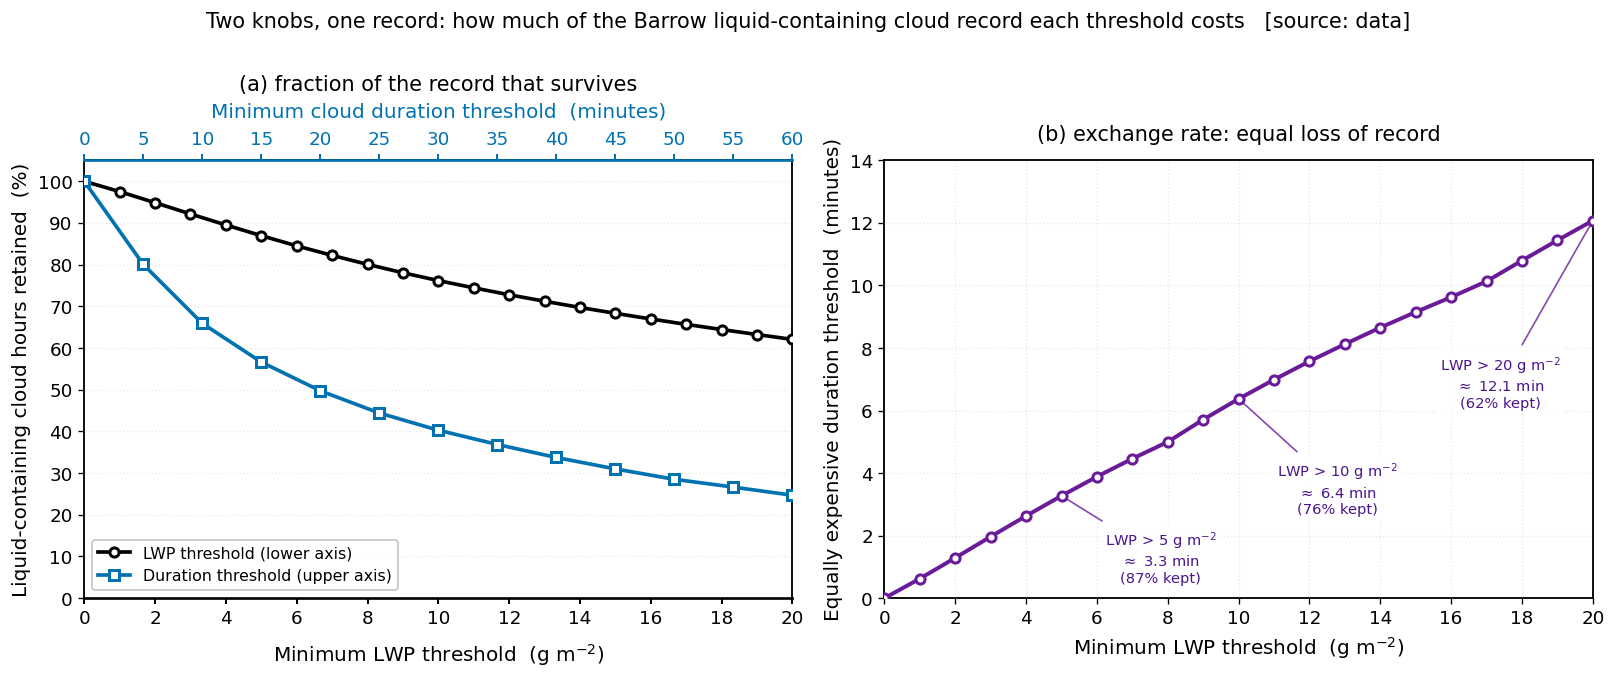

In [9]:
lwp_frac = lwp_total_h / at_lwp(lwp_total_h, 0.0)
dur_frac = duration_total_h / duration_total_h[0]

# Invert the (monotone decreasing) duration curve at each LWP threshold.
equiv_duration_min = np.interp(
    lwp_frac[::-1], dur_frac[::-1], duration_threshold_min[::-1]
)[::-1]

fig, (axa, axb) = plt.subplots(1, 2, figsize=(13.6, 5.6))

# --- (a) retained fraction --------------------------------------------------
ax_dur2 = axa.twiny()
axa.plot(lwp_threshold_gm2[lwp_plot], 100 * lwp_frac[lwp_plot], "o-", color=C_LWP,
         lw=2.2, zorder=4, label="LWP threshold (lower axis)", **lwp_mk)
ax_dur2.plot(duration_threshold_min[dur_plot], 100 * dur_frac[dur_plot], "s-",
             color=C_DUR, lw=2.2, zorder=4,
             label="Duration threshold (upper axis)", **dur_mk)

axa.set_xlim(*LWP_PLOT_RANGE_GM2)
axa.xaxis.set_major_locator(MultipleLocator(2))
axa.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)", color=C_LWP, labelpad=8)
axa.tick_params(axis="x", colors=C_LWP, width=1.2)
axa.spines["bottom"].set_color(C_LWP)
axa.spines["bottom"].set_linewidth(1.6)

ax_dur2.set_xlim(0, DUR_AXIS_MAX_MIN)
ax_dur2.xaxis.set_major_locator(MultipleLocator(5))
ax_dur2.set_xlabel("Minimum cloud duration threshold  (minutes)", color=C_DUR, labelpad=8)
ax_dur2.tick_params(axis="x", colors=C_DUR, width=1.2)
ax_dur2.spines["top"].set_color(C_DUR)
ax_dur2.spines["top"].set_linewidth(1.6)
for s in ("bottom", "left", "right"):
    ax_dur2.spines[s].set_visible(False)

axa.set_ylabel("Liquid-containing cloud hours retained  (%)")
axa.set_ylim(0, 105)
axa.yaxis.set_major_locator(MultipleLocator(10))
axa.grid(axis="y", alpha=0.28, ls=":")
axa.set_axisbelow(True)
# for lvl in (90, 75, 50):
#     axa.axhline(lvl, color="0.45", lw=0.9, ls=(0, (2, 3)), zorder=1)
#     axa.annotate(f"{lvl}%", xy=(0.012, lvl), xycoords=("axes fraction", "data"),
#                  va="bottom", ha="left", fontsize=8.5, color="0.35")

h = axa.get_legend_handles_labels()[0] + ax_dur2.get_legend_handles_labels()[0]
l = axa.get_legend_handles_labels()[1] + ax_dur2.get_legend_handles_labels()[1]
axa.legend(h, l, loc="lower left", fontsize=9.5)
axa.set_title("(a) fraction of the record that survives", pad=42)

# --- (b) exchange rate ------------------------------------------------------
axb.plot(lwp_threshold_gm2[lwp_plot], equiv_duration_min[lwp_plot], "o-",
         color="#6A1B9A", lw=2.4, zorder=4, **lwp_mk)
axb.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)")
axb.set_ylabel("Equally expensive duration threshold  (minutes)")
axb.set_xlim(*LWP_PLOT_RANGE_GM2)
axb.set_ylim(0, 14)
axb.xaxis.set_major_locator(MultipleLocator(2))
axb.yaxis.set_major_locator(MultipleLocator(2))
axb.grid(alpha=0.28, ls=":")
axb.set_axisbelow(True)
axb.set_title("(b) exchange rate: equal loss of record", pad=12)

for x, tx, ty in ((5.0, 7.8, 1.3), (10.0, 12.8, 3.5), (20.0, 17.4, 6.9)):
    y = float(np.interp(x, lwp_threshold_gm2[lwp_plot], equiv_duration_min[lwp_plot]))
    pct = 100 * at_lwp(lwp_frac, x)
    axb.annotate(f"LWP > {x:.0f} g m$^{{-2}}$\n$\\approx$ {y:.1f} min\n({pct:.0f}% kept)",
                 xy=(x, y), xytext=(tx, ty), fontsize=8.8, ha="center", va="center",
                 color="#4A148C",
                 bbox=dict(boxstyle="round,pad=0.28", fc="white", ec="none", alpha=0.9),
                 arrowprops=dict(arrowstyle="-", color="#6A1B9A", lw=1.0, alpha=0.8))

fig.suptitle("Two knobs, one record: how much of the Barrow liquid-containing cloud "
             f"record each threshold costs   [source: {DATA_SOURCE}]",
             y=1.005, fontsize=12.5)
fig.tight_layout()
fig.savefig(FIG_DIR
            / f"barrow_liquid_hours_threshold_retention_and_exchange_{DATA_SOURCE}.png", dpi=350)
plt.show()

### 6b. Export panel (a) for the ERA5 comparison

The ERA5 module (`ERA5/surface_energy_budget/plot_lwp_histogram_by_surface_class.py`,
`fig_liquid_retention_era5_vs_obs`) draws panel (a) side by side with its ERA5
counterpart on a shared y axis. It reads the two curves from this file rather
than re-implementing Genie's CSV conventions, so this cell is the single point
where the observational numbers cross over. Same pattern as
`genie_arm_seasonal_hours.txt`.


In [10]:
# ---------------------------------------------------------------------------
# Export the two retained-fraction curves of panel (a) for the ERA5 side.
#
# ERA5/surface_energy_budget/plot_lwp_histogram_by_surface_class.py draws the
# ERA5-vs-observations comparison figure and reads this file for the
# observational half, so it does not have to know about Genie's CSV layout.
# Follows the precedent of genie_arm_seasonal_hours.txt in the same folder --
# including the .txt extension: the repo .gitignore drops *.csv, and this
# file must be versioned for the ERA5 notebook to work on a fresh clone.
#
# Both curves are normalised exactly as panel (a) is: the LWP curve to its
# LWP > 0 g m-2 value, the duration curve to its no-cutoff (tau = 0) value.
# The full sweeps are written, including the sub-zero LWP thresholds under the
# `data` source (retained_pct > 100 there, by construction) and the duration
# tail beyond 60 min; the plotting side chooses its own ranges.
# ---------------------------------------------------------------------------
EXPORT_PATH = Path("../ERA5/surface_energy_budget/genie_arm_retained_fraction.txt")

_rows = []
_lwp_ref_h = at_lwp(lwp_total_h, 0.0)
for x, h in zip(lwp_threshold_gm2, lwp_total_h):
    _rows.append(("lwp", "g m-2", float(x), float(h), 100.0 * float(h) / _lwp_ref_h))
_dur_ref_h = float(duration_total_h[0])
for t, h in zip(duration_threshold_min, duration_total_h):
    _rows.append(("duration", "min", float(t), float(h), 100.0 * float(h) / _dur_ref_h))
_export = pd.DataFrame(
    _rows, columns=["knob", "threshold_unit", "threshold", "hours_per_season", "retained_pct"]
)

_header = "\n".join([
    "# DOE ARM Utqiagvik liquid-containing cloud hours retained vs threshold",
    "# ==========================================================================",
    "#",
    f"# Written by barrow_liquidContaining_cloud_susceptibility_fromGenies_data.ipynb",
    f"# from Genie Lorenzo Pearson's exports, source = {DATA_SOURCE!r}.",
    f"# {N_SEASONS} cold seasons, 2014/15 - 2024/25, Oct 1 - Mar 31.",
    "#",
    "# knob = 'lwp'      : minimum LWP threshold, g m-2, no duration cutoff.",
    "#                     retained_pct is relative to the LWP > 0 g m-2 value",
    f"#                     ({_lwp_ref_h:.1f} h/season). Sub-zero thresholds are",
    "#                     the MWR noise floor and exceed 100% by construction.",
    "# knob = 'duration' : minimum cloud duration threshold, minutes, with the",
    "#                     90 s clear-sky gap bridging of Genie's pipeline.",
    "#                     retained_pct is relative to the no-cutoff value",
    f"#                     ({_dur_ref_h:.1f} h/season).",
    "#",
    "# The two baselines differ because the duration analysis bridges 90 s gaps",
    "# and the LWP sweep does not; each curve is normalised to ITS OWN baseline.",
    "#",
])
with open(EXPORT_PATH, "w") as _f:
    _f.write(_header + "\n")
    _export.to_csv(_f, index=False, float_format="%.4f")
print(f"wrote {EXPORT_PATH.resolve()}  ({len(_export)} rows)")
print(_export.groupby("knob").agg(n=("threshold", "size"),
                                  thr_min=("threshold", "min"),
                                  thr_max=("threshold", "max")))


wrote /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/genie_arm_retained_fraction.txt  (111 rows)
           n  thr_min  thr_max
knob                          
duration  80      0.0    395.0
lwp       31    -10.0     20.0


## 7. What the curves say

In [11]:
print(f"[{DATA_SOURCE}]  liquid-containing hours per season\n")
print(f"  {'threshold':<28s}{'hours':>9s}{'% kept':>9s}")
print(f"  {'none (LWP > 0)':<28s}{at_lwp(lwp_total_h, 0.0):9.0f}{100.0:9.1f}")
for x in (5.0, 10.0, 20.0):
    print(f"  {'LWP > ' + format(x, '.0f') + ' g m-2':<28s}"
          f"{at_lwp(lwp_total_h, x):9.0f}{100 * at_lwp(lwp_frac, x):9.1f}")
for t in (5, 10, 20):
    print(f"  {'duration >= ' + str(t) + ' min':<28s}"
          f"{at_duration(duration_total_h, t):9.0f}"
          f"{100 * at_duration(dur_frac, t):9.1f}")

print(f"\n  LWP curve slope, 0 to 20 g m-2 : "
      f"{(at_lwp(lwp_total_h, 0.0) - at_lwp(lwp_total_h, 20.0)) / 20:.1f} "
      f"h/season per g m-2")
print(f"  exchange rate at 20 g m-2      : "
      f"{float(np.interp(20.0, lwp_threshold_gm2[lwp_plot], equiv_duration_min[lwp_plot])):.1f}"
      f" min")

print("\n\nfraction of each category retained\n")
print(f"  {'threshold':<26s}" + "".join(f"{lab:>17s}" for lab in CAT_LABELS))
for x in (5.0, 10.0, 20.0):
    vals = "".join(
        f"{100 * at_lwp(lwp_hours[c], x) / at_lwp(lwp_hours[c], 0.0):16.1f}%"
        for c in CATS
    )
    print(f"  {'LWP > ' + format(x, '.0f') + ' g m-2':<26s}" + vals)
for t in (5, 10, 20):
    vals = "".join(
        f"{100 * at_duration(duration_hours[c], t) / duration_hours[c][0]:16.1f}%"
        for c in CATS
    )
    print(f"  {'duration >= ' + str(t) + ' min':<26s}" + vals)

[data]  liquid-containing hours per season

  threshold                       hours   % kept
  none (LWP > 0)                   1450    100.0
  LWP > 5 g m-2                    1260     86.9
  LWP > 10 g m-2                   1104     76.2
  LWP > 20 g m-2                    900     62.1
  duration >= 5 min                1248     80.1
  duration >= 10 min               1027     65.9
  duration >= 20 min                775     49.7

  LWP curve slope, 0 to 20 g m-2 : 27.5 h/season per g m-2
  exchange rate at 20 g m-2      : 12.1 min


fraction of each category retained

  threshold                       liquid only   liquid + mixed       mixed only
  LWP > 5 g m-2                         80.5%            92.4%            78.6%
  LWP > 10 g m-2                        64.9%            85.3%            63.5%
  LWP > 20 g m-2                        45.0%            74.5%            49.5%
  duration >= 5 min                     80.1%            83.5%            63.7%
  duration >= 10 min  

Numbers quoted below are from the default `data` source. `digitized_plot`
gives the same percentages to within 0.55 points over the 0-60 min range
plotted here; section 8 prints the worst case over the full sweep.

**Duration is by far the more expensive knob.** Ten minutes of required
persistence costs 34% of the record; the *entire* 20 g m-2 LWP sweep,
which is as far as Genie's figure goes, costs 38%. Panel (b) puts the exchange
rate at a nearly constant **0.6 min per g m-2** across the whole sweep
(equivalently, 1 minute of required persistence costs about as much as
1.6 g m-2 of LWP), so the full 20 g m-2 cut buys the same loss as a
12-minute persistence requirement, and nothing milder.

The reason is in the cloud-duration distribution reproduced in panel (c) of
section 3: it is steeply peaked at short durations with a long thin tail. Short
episodes are individually negligible but there are enough of them that they
carry a third of the total hours. The LWP curve, by contrast, is close to
linear over 0-20 g m-2, losing about 27 h/season per g m-2 -- there
is no pile-up of hours at low LWP the way there is at short duration.

**By category, the two knobs do not fall on the same one.** `liq_mixed`
survives both best (74.5% retained at LWP > 20 g m-2, 54.7% at 20 min,
against 45-50% and 25-50% for the other two). That is close to a definition: an
episode is classified `liq_mixed` only if it contains both a liquid-only and a
mixed-phase period, which forces it to be long, and long episodes carry more
liquid. The interesting split is between the other two categories. The LWP knob
bites hardest on `liq_only` (45.0% retained at 20 g m-2, against 49.5% for
`mixed_only`); the duration knob bites hardest on `mixed_only` by a wide margin
(24.6% retained at 20 min, against 50.2% for `liq_only`). Purely mixed-phase
episodes at Barrow are the short-lived ones.

## 8. The two sources, differenced

Loads both and compares them, so the digitization can be checked against the
CSV it was standing in for.

In [12]:
both = {}
for name, loader in LOADERS.items():
    try:
        both[name] = loader()
    except (FileNotFoundError, ValueError) as exc:
        print(f"could not load {name!r}: {exc}")

if len(both) == 2:
    a, b = both["data"], both["digitized_plot"]

    print("LWP sweep, liquid-containing hours per season\n")
    print(f"  {'LWP':>5s}{'data':>10s}{'digitized':>12s}{'diff':>9s}{'% diff':>9s}")
    tot_a = sum(a["lwp_hours"][c] for c in CATS)
    tot_b = sum(b["lwp_hours"][c] for c in CATS)
    for x in (0.0, 1.0, 2.0, 5.0, 10.0, 15.0, 20.0):
        va = tot_a[int(np.flatnonzero(np.isclose(a["lwp_threshold_gm2"], x))[0])]
        vb = tot_b[int(np.flatnonzero(np.isclose(b["lwp_threshold_gm2"], x))[0])]
        print(f"  {x:5.0f}{va:10.1f}{vb:12.1f}{vb - va:9.1f}{100 * (vb - va) / va:9.2f}")

    print("\nDuration sweep, fraction of the record retained (%)\n")
    print(f"  {'tau':>5s}{'data':>10s}{'digitized':>12s}{'diff':>9s}")
    fa = sum(a["duration_hours"][c] for c in CATS)
    fb = sum(b["duration_hours"][c] for c in CATS)
    fa = 100 * fa / fa[0]
    fb = 100 * fb / fb[0]
    for t in (0, 5, 10, 15, 20, 30, 45, 60):
        ia = np.flatnonzero(np.isclose(a["duration_threshold_min"], t))
        ib = np.flatnonzero(np.isclose(b["duration_threshold_min"], t))
        if ia.size and ib.size:
            print(f"  {t:5d}{fa[ia[0]]:10.1f}{fb[ib[0]]:12.1f}"
                  f"{fb[ib[0]] - fa[ia[0]]:9.2f}")

    # Largest disagreement anywhere on the common part of the duration sweep.
    common = np.intersect1d(a["duration_threshold_min"], b["duration_threshold_min"])
    ja = np.searchsorted(a["duration_threshold_min"], common)
    jb = np.searchsorted(b["duration_threshold_min"], common)
    max_pt = float(np.abs(fb[jb] - fa[ja]).max())
    max_at = float(common[int(np.abs(fb[jb] - fa[ja]).argmax())])
    print("\nThe retained-fraction curves -- which every conclusion above rests on --")
    print(f"never differ by more than {max_pt:.2f} percentage points "
          f"(worst at tau = {max_at:.0f} min).")

LWP sweep, liquid-containing hours per season

    LWP      data   digitized     diff   % diff
      0    1449.6      1450.8      1.2     0.08
      1    1413.6      1413.7      0.1     0.01
      2    1375.1      1376.6      1.5     0.11
      5    1260.4      1260.4      0.0     0.00
     10    1104.2      1102.9     -1.3    -0.11
     15     990.3       991.0      0.7     0.08
     20     899.6       900.8      1.2     0.14

Duration sweep, fraction of the record retained (%)

    tau      data   digitized     diff
      0     100.0       100.0    -0.00
      5      80.1        80.3     0.26
     10      65.9        66.2     0.28
     15      56.6        56.8     0.23
     20      49.7        49.9     0.15
     30      40.3        40.2    -0.10
     45      31.0        30.8    -0.23
     60      24.7        24.1    -0.53

The retained-fraction curves -- which every conclusion above rests on --
never differ by more than 0.73 percentage points (worst at tau = 90 min).


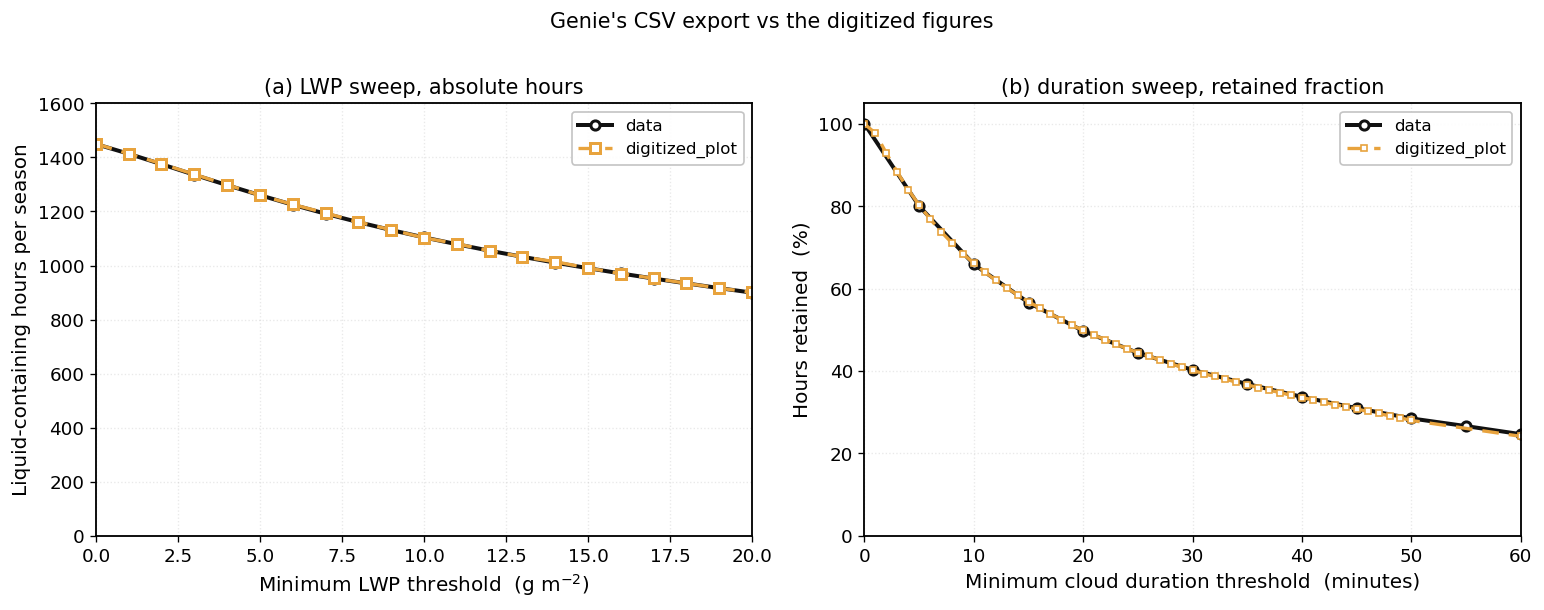

In [13]:
if len(both) == 2:
    fig, (axa, axb) = plt.subplots(1, 2, figsize=(13.0, 5.0))
    styles = {"data": dict(color="#111111", lw=2.4, ls="-", marker="o"),
              "digitized_plot": dict(color="#E8A33D", lw=2.0, ls=(0, (5, 3)),
                                     marker="s")}
    for name, d in both.items():
        tot = sum(d["lwp_hours"][c] for c in CATS)
        m = ((d["lwp_threshold_gm2"] >= LWP_PLOT_RANGE_GM2[0])
             & (d["lwp_threshold_gm2"] <= LWP_PLOT_RANGE_GM2[1]))
        axa.plot(d["lwp_threshold_gm2"][m], tot[m], label=name,
                 **marker_kwargs(int(m.sum())), **styles[name])

        dtot = sum(d["duration_hours"][c] for c in CATS)
        m2 = d["duration_threshold_min"] <= DUR_AXIS_MAX_MIN
        axb.plot(d["duration_threshold_min"][m2], 100 * dtot[m2] / dtot[0],
                 label=name, **marker_kwargs(int(m2.sum())), **styles[name])

    axa.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)")
    axa.set_ylabel("Liquid-containing hours per season")
    axa.set_xlim(*LWP_PLOT_RANGE_GM2)
    axa.set_ylim(0, 1600)
    axa.grid(alpha=0.28, ls=":")
    axa.set_axisbelow(True)
    axa.legend(fontsize=10)
    axa.set_title("(a) LWP sweep, absolute hours")

    axb.set_xlabel("Minimum cloud duration threshold  (minutes)")
    axb.set_ylabel("Hours retained  (%)")
    axb.set_xlim(0, DUR_AXIS_MAX_MIN)
    axb.set_ylim(0, 105)
    axb.grid(alpha=0.28, ls=":")
    axb.set_axisbelow(True)
    axb.legend(fontsize=10)
    axb.set_title("(b) duration sweep, retained fraction")

    fig.suptitle("Genie's CSV export vs the digitized figures", y=1.01, fontsize=12.5)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "barrow_liquid_hours_source_comparison.png")
    plt.show()

## 9. Per-cloud durations -- Genie's event list (`cloudDuration_ALL.csv`)

A third product from Genie (2026-09-17): the duration, in minutes, of **every
liquid-containing cloud** in the eleven cold seasons, one row per cloud, no
season labels. Non-precipitating, LWP threshold 0 g m⁻². Every value is a
multiple of 0.5 min -- one 30-s sample -- so the shortest possible cloud is a
single sample.

This is the raw material behind the cloud-length histogram of section 3(c),
and it is better than the histogram for the threshold question: the histogram
gives the hours in each *bin*, so the retained-hours curve of section 4 is a
reverse cumulative sum that can only be evaluated at bin edges (5 min apart in
the CSV). From the event list the curve is exact at every 0.5 min:

$$H(\tau) \;=\; \frac{1}{60 \cdot 11} \sum_{i:\; d_i \ge \tau} d_i$$

This is the same operation as the LWP sweep -- total time in all clouds that
pass the cut -- so the two knobs are finally computed the same way from the
same kind of data, rather than one from a sweep and one from a binned
histogram.

### 9a. Is the list consistent with the seasonal totals?

It should be, in principle: every liquid-containing 30-s sample belongs to
exactly one cloud, so the durations should sum to the seasonal totals of
`liquid_containing_clouds_yearly_totals_ver2.csv` (÷120 for hours) -- provided
both were built with the same phase classification, the same LWP threshold and
the same precipitation rule, and no cloud is dropped at a data gap or a season
boundary. The cell below tests that, and then compares the list against the
older products in this notebook.


In [14]:
DURATION_LIST_FILE = CSV_DIR / "cloudDuration_ALL.csv"
VER2_SEASONAL_FILE = CSV_DIR / "liquid_containing_clouds_yearly_totals_ver2.csv"
SAMPLE_MIN = 0.5      # one 30-s sample, in minutes: the resolution of every duration

# One column, header '0' (a pandas Series export), one cloud per row.
dur_min = pd.read_csv(DURATION_LIST_FILE).iloc[:, 0].to_numpy(float)
if not np.all(np.isfinite(dur_min)) or (dur_min <= 0).any():
    raise ValueError("cloudDuration_ALL.csv holds non-finite or non-positive durations")
if not np.allclose(dur_min / SAMPLE_MIN, np.round(dur_min / SAMPLE_MIN)):
    raise ValueError("durations are not all multiples of one 30-s sample")

# ver2 seasonal totals: header ',0', then '<season index>,<count of 30-s samples>'
ver2_counts = pd.read_csv(VER2_SEASONAL_FILE, index_col=0).iloc[:, 0].to_numpy(float)
if ver2_counts.size != N_SEASONS:
    raise ValueError(f"expected {N_SEASONS} seasons in {VER2_SEASONAL_FILE.name}, "
                     f"got {ver2_counts.size}")

# Sorted copy and cumulative cloud time, shared by the histogram, CDF and
# threshold cells below. dur_cum_min[k] is the time in the k + 1 shortest clouds.
dur_sorted_min = np.sort(dur_min)
dur_cum_min = np.cumsum(dur_sorted_min)

list_total_h = dur_min.sum() / MINUTES_PER_HOUR             # whole record
ver2_total_h = ver2_counts.sum() / SAMPLES_PER_HOUR_30S     # whole record
gap_h = list_total_h - ver2_total_h

print(f"cloudDuration_ALL.csv: {dur_min.size:,} clouds over {N_SEASONS} seasons\n")
print(f"  {'duration (min)':<18}{'min':>7}{'median':>9}{'mean':>8}{'max':>9}")
print(f"  {'':<18}{dur_min.min():>7.1f}{np.median(dur_min):>9.1f}"
      f"{dur_min.mean():>8.1f}{dur_min.max():>9.1f}\n")

print("consistency with the seasonal totals (whole record, all 11 seasons):\n")
print(f"  {'':<44}{'hours':>10}{'h/season':>11}")
print(f"  {'sum of every cloud duration':<44}{list_total_h:>10,.1f}"
      f"{list_total_h / N_SEASONS:>11,.1f}")
print(f"  {'ver2 seasonal totals (samples / 120)':<44}{ver2_total_h:>10,.1f}"
      f"{ver2_total_h / N_SEASONS:>11,.1f}")
print(f"  {'difference, list - ver2':<44}{gap_h:>+10,.1f}"
      f"{gap_h / N_SEASONS:>+11,.1f}   ({100 * gap_h / ver2_total_h:+.1f}%)")

# The earlier products in this notebook, for the same record, in h/season.
list_hps = list_total_h / N_SEASONS
refs = {
    "ver1 seasonal table (with_liquid, pre-fix)": 1474.5,
    "LWP sweep at LWP > 0 g m-2 (section 2)": at_lwp(lwp_total_h, 0.0),
    "LWP sweep at LWP > -10 g m-2 (no cut)": (at_lwp(lwp_total_h, -10.0)
                                             if (lwp_threshold_gm2 < 0).any() else np.nan),
    "binned duration histogram (section 4)": float(duration_total_h[0]),
}
print(f"\n  against the earlier products, h/season:\n")
print(f"  {'':<44}{'value':>10}{'list / it':>11}")
for name, v in refs.items():
    if np.isfinite(v):
        print(f"  {name:<44}{v:>10,.1f}{list_hps / v:>11.3f}")


cloudDuration_ALL.csv: 64,594 clouds over 11 seasons

  duration (min)        min   median    mean      max
                        0.5      3.0    16.2   3218.5

consistency with the seasonal totals (whole record, all 11 seasons):

                                                   hours   h/season
  sum of every cloud duration                   17,392.5    1,581.1
  ver2 seasonal totals (samples / 120)          18,574.0    1,688.5
  difference, list - ver2                       -1,181.5     -107.4   (-6.4%)

  against the earlier products, h/season:

                                                   value  list / it
  ver1 seasonal table (with_liquid, pre-fix)     1,474.5      1.072
  LWP sweep at LWP > 0 g m-2 (section 2)         1,449.6      1.091
  LWP sweep at LWP > -10 g m-2 (no cut)          1,542.2      1.025
  binned duration histogram (section 4)          1,558.9      1.014


**They do not match.** The durations sum to 17,392 h, the ver2 seasonal
totals to 18,574 h: the list is **1,182 h short over the record, 107 h/season,
−6.4%**. Since a list of clouds cannot contain *more* than the samples that
make them, a shortfall means either that samples were left out of every cloud,
or that the two products were not built from the same sample set.

The comparison with the older products points to the second. The list is
**+7.2% above the ver1 (pre-fix) with-liquid total** of 1474.5 h/season and
**+1.4% above the section-4 histogram** (1559 h/season) -- and the ver2
correction moved ~215 h/season of mixed-phase time into the liquid-containing
category. A list built from the *corrected* classification would be expected
around 1689 h/season or above, not 1581. The simplest reading is that
`cloudDuration_ALL.csv` was generated with the **pre-correction phase
classification**, and carries the same few-percent excess over the LWP sweep
that the old histogram did. That is an inference from four numbers, not a
statement from Genie -- moderately confident, and worth one question to her:
*was the duration list produced after the mixed-phase fix, and does the
segmentation drop or truncate any clouds (data gaps, season boundaries)?*

There is no per-season check possible: the file carries no season labels.

### 9b. The list against the old binned histogram -- the shape has changed

The totals agree to 1.4%, but the **distribution does not**. The next cell
bins the list into the same 5-min bins as `cloudlengths_5mins.csv` and
compares the hours in each.


In [15]:
# Hours per season contributed by clouds in each 5-min bin: the list, binned
# the way the section-3(c) histogram is, against the CSV histogram itself.
_edges = ds["hist_edges_min"]
_bin = np.clip(np.searchsorted(_edges, dur_min, side="right") - 1, 0, _edges.size - 2)
# Clouds beyond the last edge are folded into the last bin so the totals match.
list_hist_hps = np.bincount(_bin, weights=dur_min, minlength=_edges.size - 1) \
    / MINUTES_PER_HOUR / N_SEASONS
old_hist_hps = sum(ds["hist_hours"][c] for c in CATS)

print(f"hours per season by cloud length, {np.diff(_edges)[0]:.0f}-min bins   [source = {DATA_SOURCE!r}]\n")
print(f"  {'bin (min)':<12}{'old histogram':>15}{'event list':>13}{'list / old':>12}")
for k in range(12):
    print(f"  {_edges[k]:>3.0f}-{_edges[k + 1]:<7.0f}{old_hist_hps[k]:>15.1f}"
          f"{list_hist_hps[k]:>13.1f}{list_hist_hps[k] / old_hist_hps[k]:>12.2f}")
k60 = int(np.flatnonzero(np.isclose(_edges, 60.0))[0])
print(f"  {'>= 60':<12}{old_hist_hps[k60:].sum():>15.1f}{list_hist_hps[k60:].sum():>13.1f}"
      f"{list_hist_hps[k60:].sum() / old_hist_hps[k60:].sum():>12.2f}")
print(f"  {'total':<12}{old_hist_hps.sum():>15.1f}{list_hist_hps.sum():>13.1f}"
      f"{list_hist_hps.sum() / old_hist_hps.sum():>12.2f}")
print(f"\n  share of all cloud hours in clouds shorter than 10 min : "
      f"old {100 * old_hist_hps[:2].sum() / old_hist_hps.sum():.0f}%   "
      f"list {100 * list_hist_hps[:2].sum() / list_hist_hps.sum():.0f}%")
print(f"  share of all cloud hours in clouds of 60 min or longer : "
      f"old {100 * old_hist_hps[k60:].sum() / old_hist_hps.sum():.0f}%   "
      f"list {100 * list_hist_hps[k60:].sum() / list_hist_hps.sum():.0f}%")


hours per season by cloud length, 5-min bins   [source = 'data']

  bin (min)     old histogram   event list  list / old
    0-5                311.0        105.0        0.34
    5-10               220.6         93.9        0.43
   10-15               144.8         70.6        0.49
   15-20               107.5         58.2        0.54
   20-25                83.1         50.2        0.60
   25-30                64.3         42.8        0.67
   30-35                53.4         36.5        0.68
   35-40                48.6         34.2        0.70
   40-45                42.7         30.6        0.72
   45-50                38.9         30.3        0.78
   50-55                29.1         24.8        0.85
   55-60                30.4         24.1        0.79
  >= 60                 384.7        979.9        2.55
  total                1558.9       1581.1        1.01

  share of all cloud hours in clouds shorter than 10 min : old 34%   list 13%
  share of all cloud hours in clouds of 60

The list puts **a third** of the hours the old histogram had in clouds
shorter than 5 min, and **2.5 times** the hours in clouds of an hour or more.
Under the old histogram 34% of all liquid-containing time was in clouds
shorter than 10 min; under the list it is 13%. That is not a units or binning
issue -- the totals agree -- it is a different segmentation of the same record
into clouds. Merging fragments across short clear gaps would do exactly this:
it moves time from many short clouds into fewer long ones while adding almost
nothing to the total. Whether that is what changed is another question for
Genie; the note under section 4 ("90 s gap bridging") described the *old*
histogram, and this notebook cannot tell which product carries it.

**Every conclusion of sections 6-7 about the duration knob rests on the old
shape.** They are recomputed from the list below.

### 9c. The distribution: histogram, mean and median

Three views of the same 64,594 clouds. Panel (a) is the count of clouds at
each 30-s step over 0-60 min -- one bar per distinct duration, since the data
are on a 0.5-min grid; panel (b) the density (clouds per minute of duration)
on log-log axes over the full range, which is the only way to see the tail --
the longest cloud is 3,218 min (54 h), and the near-straight decline is a
power-law-like tail. Panel (c) weights each cloud by its duration and divides by the bin width in
log₁₀(minutes), so the *area* under the bars on the log axis is hours per
season: the analogue of Genie's histogram in section 3(c) drawn for a log
axis, and the quantity the threshold curve integrates.

The mean (16.2 min) sits far to the right of the median (3.0 min) because the
distribution is heavy-tailed: 15% of clouds are a single 30-s sample and 38%
last 1.5 min or less, yet the 5% of clouds that last an hour or more carry
62% of the hours. Panel (c) marks the
duration-weighted median -- the length below which half of all cloud *hours*
fall -- which is where the threshold question actually lives.


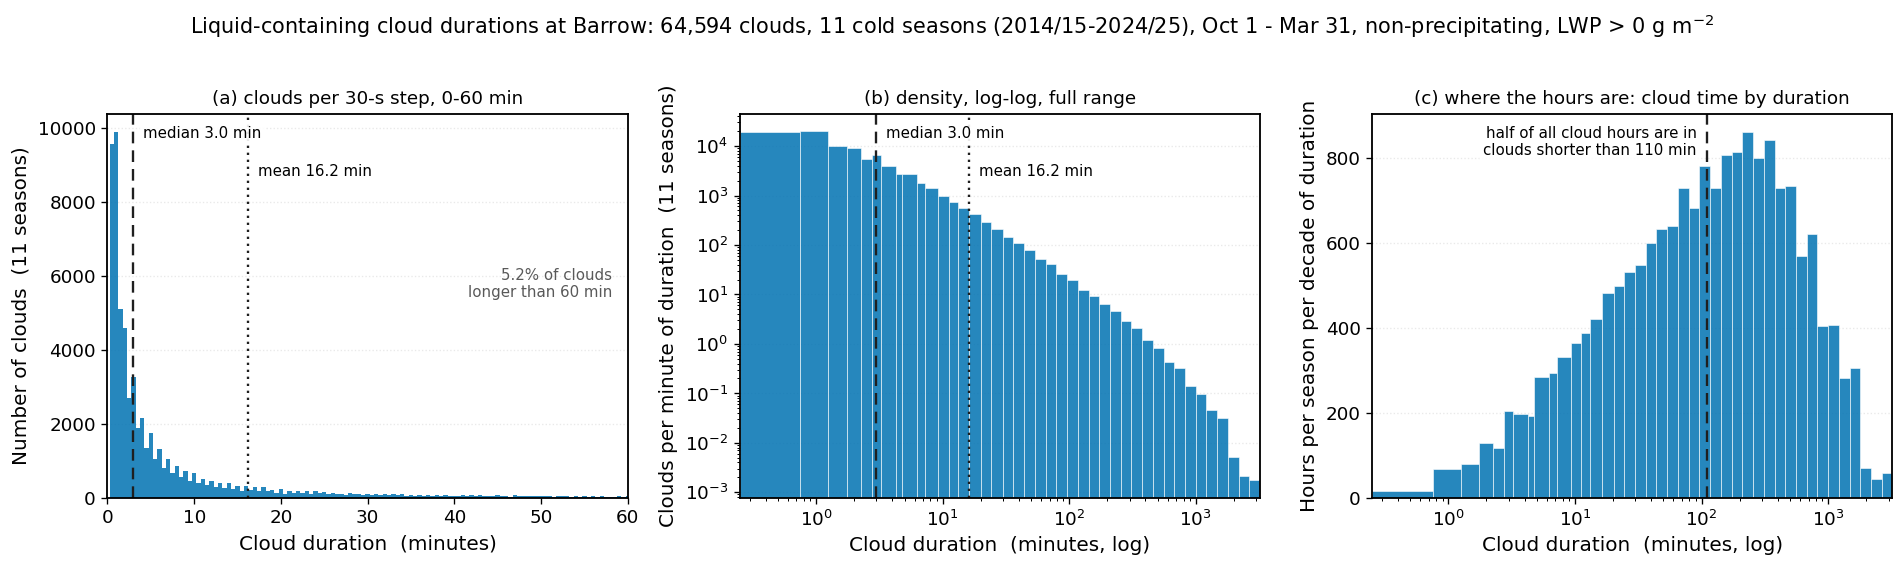

clouds: 64,594   mean 16.16 min   median 3.00 min   duration-weighted median 110.0 min
single-sample clouds (0.5 min): 14.8%   <= 1.5 min: 38.0%   <= 5 min: 65.4%   >= 60 min: 5.2%


In [16]:
mean_min = float(dur_min.mean())
median_min = float(np.median(dur_min))

# Duration-weighted median: the length below which half of all cloud HOURS
# fall, read off the cumulative cloud time.
weighted_median_min = float(
    dur_sorted_min[np.searchsorted(dur_cum_min, 0.5 * dur_cum_min[-1])])

# Log-spaced bin edges snapped to the 0.5-min sample grid and offset by a
# quarter sample, so every bin is at least one sample wide and every discrete
# duration falls inside a bin rather than on an edge. Plain geomspace edges
# are narrower than the sample spacing below ~5 min and leave empty bins.
_raw = np.geomspace(SAMPLE_MIN, dur_min.max() + SAMPLE_MIN, 46)
edges_log = np.unique(np.round(_raw / SAMPLE_MIN) * SAMPLE_MIN) - 0.25 * SAMPLE_MIN * 2

_style = dict(color="0.12", lw=1.4)
_txt = dict(fontsize=9, ha="left", va="top",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9))

fig, (axa, axb, axc) = plt.subplots(1, 3, figsize=(16.0, 4.6))

# --- (a) clouds per 30-s step, 0-60 min --------------------------------------
# One bin per distinct duration: the data are on a 0.5-min grid, so a finer
# bin would be empty and a coarser one would merge unequal counts. Edges sit
# a quarter sample either side of each value.
edges_a = np.arange(0.25 * SAMPLE_MIN * 2, 60.0 + SAMPLE_MIN, SAMPLE_MIN)
axa.hist(dur_min, bins=edges_a, color=C_DUR, alpha=0.85, edgecolor="none")
axa.axvline(median_min, ls=(0, (5, 3)), **_style)
axa.axvline(mean_min, ls=(0, (1, 2)), **_style)
axa.annotate(f"median {median_min:.1f} min", xy=(median_min, 0.97),
             xycoords=("data", "axes fraction"), xytext=(6, 0), textcoords="offset points",
             **_txt)
axa.annotate(f"mean {mean_min:.1f} min", xy=(mean_min, 0.87),
             xycoords=("data", "axes fraction"), xytext=(6, 0), textcoords="offset points",
             **_txt)
beyond = 100 * np.mean(dur_min > 60.0)
axa.annotate(f"{beyond:.1f}% of clouds\nlonger than 60 min", xy=(0.97, 0.60),
             xycoords="axes fraction", ha="right", va="top", fontsize=9, color="0.35")
axa.set_xlim(0, 60)
axa.set_xlabel("Cloud duration  (minutes)")
axa.set_ylabel("Number of clouds  (11 seasons)")
axa.set_title("(a) clouds per 30-s step, 0-60 min", fontsize=11)
axa.grid(axis="y", alpha=0.28, ls=":")
axa.set_axisbelow(True)

# --- (b) density on log-log axes, full range ---------------------------------
# Counts per bin divided by the bin width in minutes, so unequal bins are
# comparable; log y because the density spans five decades. This is the view
# that shows the tail: a straight line here is a power law.
_n, _ = np.histogram(dur_min, bins=edges_log)
_dens = _n / np.diff(edges_log)
axb.bar(edges_log[:-1], _dens, width=np.diff(edges_log), align="edge",
        color=C_DUR, alpha=0.85, edgecolor="white", lw=0.4)
axb.set_xscale("log")
axb.set_yscale("log")
axb.set_xlim(edges_log[0], edges_log[-1])
axb.axvline(median_min, ls=(0, (5, 3)), **_style)
axb.axvline(mean_min, ls=(0, (1, 2)), **_style)
axb.annotate(f"median {median_min:.1f} min", xy=(median_min, 0.97),
             xycoords=("data", "axes fraction"), xytext=(6, 0), textcoords="offset points",
             **_txt)
axb.annotate(f"mean {mean_min:.1f} min", xy=(mean_min, 0.87),
             xycoords=("data", "axes fraction"), xytext=(6, 0), textcoords="offset points",
             **_txt)
axb.set_xlabel("Cloud duration  (minutes, log)")
axb.set_ylabel("Clouds per minute of duration  (11 seasons)")
axb.set_title("(b) density, log-log, full range", fontsize=11)
axb.grid(axis="y", alpha=0.28, ls=":")
axb.set_axisbelow(True)

# --- (c) hours per season contributed, per decade of duration ----------------
# Each cloud weighted by its own duration, then divided by the bin width in
# log10(minutes): the density whose AREA on a log axis is hours per season.
# Raw hours per bin would alternate with the snapped bin widths below 10 min.
_h, _ = np.histogram(dur_min, bins=edges_log,
                     weights=dur_min / MINUTES_PER_HOUR / N_SEASONS)
_h_per_decade = _h / np.diff(np.log10(edges_log))
axc.bar(edges_log[:-1], _h_per_decade, width=np.diff(edges_log), align="edge",
        color=C_DUR, alpha=0.85, edgecolor="white", lw=0.4)
axc.set_xscale("log")
axc.set_xlim(edges_log[0], edges_log[-1])
axc.axvline(weighted_median_min, ls=(0, (5, 3)), **_style)
axc.annotate(f"half of all cloud hours are in\nclouds shorter than "
             f"{weighted_median_min:.0f} min", xy=(weighted_median_min, 0.97),
             xycoords=("data", "axes fraction"), xytext=(-6, 0), textcoords="offset points",
             ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9))
axc.set_xlabel("Cloud duration  (minutes, log)")
axc.set_ylabel("Hours per season per decade of duration")
axc.set_title("(c) where the hours are: cloud time by duration", fontsize=11)
axc.grid(axis="y", alpha=0.28, ls=":")
axc.set_axisbelow(True)

fig.suptitle(f"Liquid-containing cloud durations at Barrow: {dur_min.size:,} clouds, "
             f"11 cold seasons (2014/15-2024/25), Oct 1 - Mar 31, non-precipitating, "
             "LWP > 0 g m$^{-2}$", y=1.02, fontsize=12.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "barrow_cloud_duration_histogram_event_list.png", dpi=350)
plt.show()

print(f"clouds: {dur_min.size:,}   mean {mean_min:.2f} min   median {median_min:.2f} min   "
      f"duration-weighted median {weighted_median_min:.1f} min")
print(f"single-sample clouds (0.5 min): {100 * np.mean(dur_min == SAMPLE_MIN):.1f}%   "
      f"<= 1.5 min: {100 * np.mean(dur_min <= 1.5):.1f}%   "
      f"<= 5 min: {100 * np.mean(dur_min <= 5):.1f}%   "
      f">= 60 min: {100 * np.mean(dur_min >= 60):.1f}%")


### 9d. Cumulative distribution functions

Two CDFs, and they answer different questions:

- **by cloud** -- the fraction of clouds with duration ≤ τ. The ordinary
  empirical CDF; its 50% crossing is the median above.
- **by hours** -- the fraction of all liquid-containing *time* that sits in
  clouds with duration ≤ τ, i.e. each cloud weighted by its own length. Its
  complement is the fraction of the record a minimum duration threshold
  retains -- the quantity sections 6-7 compare against the LWP knob (up to
  the convention at exactly τ: "at least τ" keeps the clouds of length τ,
  one 30-s step apart from "≤ τ").

The gap between the two curves is the heavy tail in one picture: at τ = 5 min
two thirds of the clouds are already counted, but only 7% of the hours.


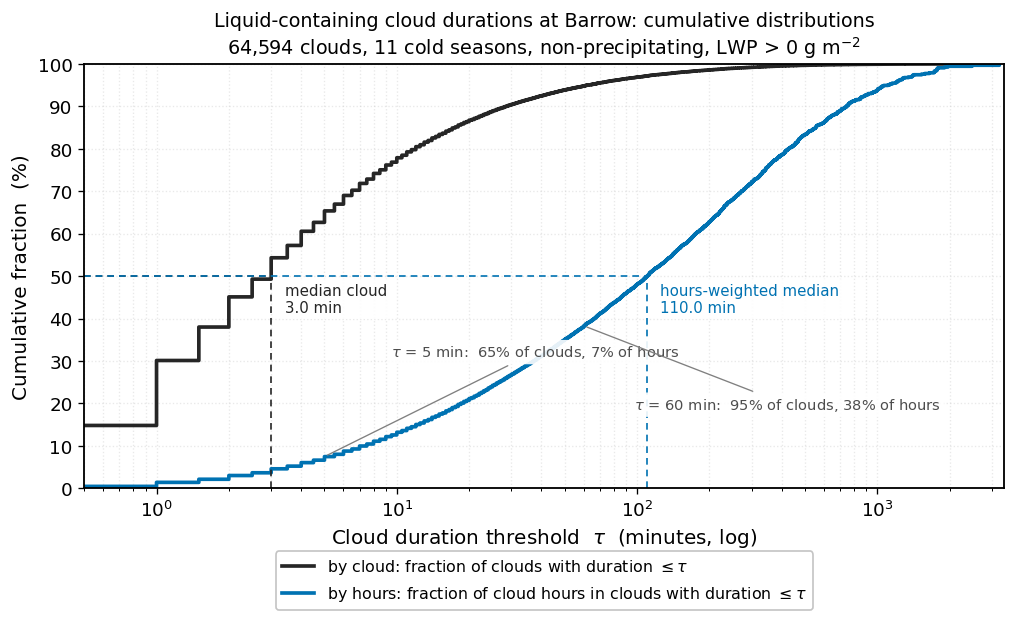

   tau (min)  clouds <= tau  hours <= tau  hours retained (>= tau)
         0.5          14.8%          0.5%                   100.0%
         1.0          30.1%          1.4%                    99.5%
         2.0          45.1%          3.0%                    97.9%
         3.0          54.3%          4.6%                    96.3%
         5.0          65.4%          7.5%                    93.4%
        10.0          77.9%         13.2%                    87.4%
        15.0          83.4%         17.5%                    83.0%
        20.0          86.8%         21.2%                    79.3%
        30.0          90.5%         26.9%                    73.4%
        60.0          94.8%         38.3%                    62.0%
       120.0          97.5%         52.0%                    48.1%
       360.0          99.4%         76.5%                    23.6%


In [17]:
# Both CDFs evaluated at every distinct duration (all multiples of 0.5 min).
tau_cdf = np.unique(dur_min)
_k_le = np.searchsorted(dur_sorted_min, tau_cdf, side="right")   # clouds <= tau
cdf_clouds = _k_le / dur_sorted_min.size
cdf_hours = dur_cum_min[_k_le - 1] / dur_cum_min[-1]

fig, ax = plt.subplots(figsize=(8.6, 5.4))
ax.step(tau_cdf, 100 * cdf_clouds, where="post", color="0.15", lw=2.2,
        label="by cloud: fraction of clouds with duration $\\leq \\tau$")
ax.step(tau_cdf, 100 * cdf_hours, where="post", color=C_DUR, lw=2.2,
        label="by hours: fraction of cloud hours in clouds with duration $\\leq \\tau$")
ax.set_xscale("log")
ax.set_xlim(SAMPLE_MIN, dur_min.max() * 1.05)
ax.set_ylim(0, 100)
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.grid(alpha=0.28, ls=":", which="both")
ax.set_axisbelow(True)

# The two medians, dropped to the axis.
for x, col, lab in ((median_min, "0.15", "median cloud"),
                    (weighted_median_min, C_DUR, "hours-weighted median")):
    ax.plot([x, x], [0, 50], color=col, lw=1.0, ls=(0, (4, 3)))
    ax.plot([SAMPLE_MIN, x], [50, 50], color=col, lw=1.0, ls=(0, (4, 3)))
    ax.annotate(f"{lab}\n{x:.1f} min", xy=(x, 50), xytext=(8, -4),
                textcoords="offset points", ha="left", va="top", fontsize=9, color=col,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9))

# A few read-offs worth having on the figure.
for t in (5.0, 60.0):
    fc = 100 * cdf_clouds[np.searchsorted(tau_cdf, t)]
    fh = 100 * cdf_hours[np.searchsorted(tau_cdf, t)]
    ax.annotate(f"$\\tau$ = {t:.0f} min:  {fc:.0f}% of clouds, {fh:.0f}% of hours",
                xy=(t, fh), xytext=(40, 60) if t < 10 else (30, -50),
                textcoords="offset points", ha="left", fontsize=8.8, color="0.3",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9),
                arrowprops=dict(arrowstyle="-", color="0.5", lw=0.8))

ax.set_xlabel("Cloud duration threshold  $\\tau$  (minutes, log)")
ax.set_ylabel("Cumulative fraction  (%)")
ax.set_title("Liquid-containing cloud durations at Barrow: cumulative distributions\n"
             f"{dur_min.size:,} clouds, 11 cold seasons, non-precipitating, LWP > 0 g m$^{{-2}}$",
             fontsize=11.5)
# Legend below the axes: every corner of the panel has a curve in it.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), fontsize=9.5, ncol=1)
fig.tight_layout()
fig.savefig(FIG_DIR / "barrow_cloud_duration_cdf_event_list.png", dpi=350)
plt.show()

# 'hours retained' keeps clouds AT LEAST tau long (the section-4 and 9e
# convention), so it is 1 - F(tau-), one 30-s step to the left of the <= column.
print(f"  {'tau (min)':>10}{'clouds <= tau':>15}{'hours <= tau':>14}{'hours retained (>= tau)':>25}")
for t in (0.5, 1, 2, 3, 5, 10, 15, 20, 30, 60, 120, 360):
    j = np.searchsorted(tau_cdf, t)
    k_lt = np.searchsorted(dur_sorted_min, t, side="left")          # clouds < tau
    kept = 1.0 - (dur_cum_min[k_lt - 1] if k_lt else 0.0) / dur_cum_min[-1]
    print(f"  {t:>10.1f}{100 * cdf_clouds[j]:>14.1f}%{100 * cdf_hours[j]:>13.1f}%"
          f"{100 * kept:>24.1f}%")


### 9e. Hours retained vs cloud-duration threshold, from the list

The retained-hours curve, exact at every 0.5 min:
$H(\tau) = \sum_{d_i \ge \tau} d_i \,/\, (60 \cdot 11)$. A cloud is kept when
it is *at least* τ long, the same convention as section 4's reverse cumulative
sum (bins at or beyond the edge). The figure repeats section 5 -- LWP threshold
on the lower axis, duration threshold on the upper -- with the duration curve
now from the list, and the section-4 curve from the binned histogram left in
as a thin dashed line so the change is visible. The two knobs are now the same
computation: total time in the clouds that pass the cut.

The baselines still differ (LWP > 0 gives 1450 h/season, the list 1581), for
the reasons in 9a, so the retained-*fraction* panel underneath is the fair
comparison, as in section 6.


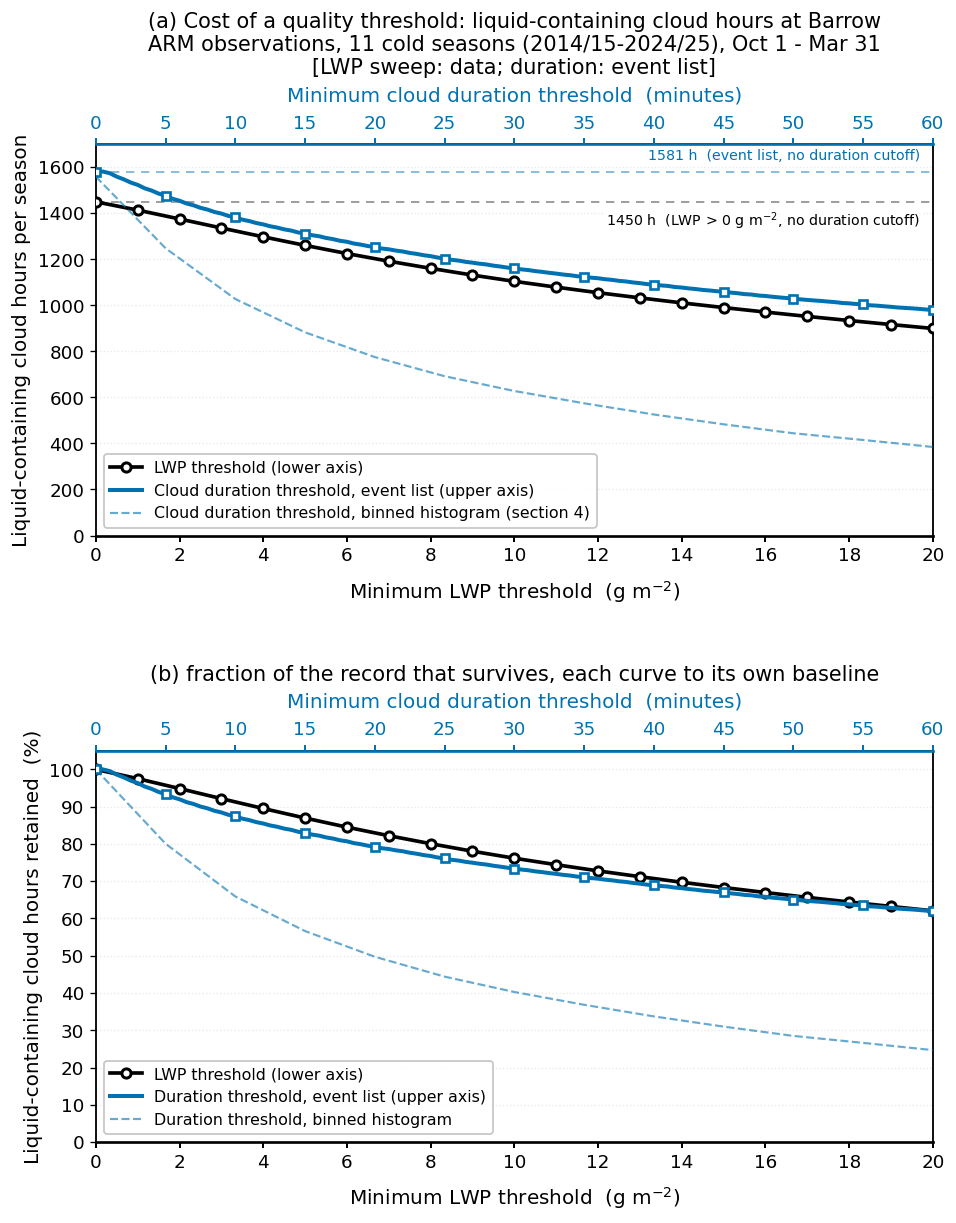

In [18]:
def hours_retained_from_list(dur_min: np.ndarray, tau_min: np.ndarray) -> np.ndarray:
    """Hours per season in clouds at least ``tau_min`` long, for each tau.

    Sort once; the time in clouds >= tau is the total less the cumulative time
    in clouds shorter than tau.
    """
    s = np.sort(dur_min)
    cum_below = np.concatenate([[0.0], np.cumsum(s)])       # time in the k shortest clouds
    k = np.searchsorted(s, tau_min, side="left")            # clouds shorter than tau
    return (cum_below[-1] - cum_below[k]) / MINUTES_PER_HOUR / N_SEASONS


# Fine sweep over the plotted range, then the long tail more coarsely.
tau_list_min = np.concatenate([np.arange(0.0, 60.0 + SAMPLE_MIN, SAMPLE_MIN),
                               np.arange(65.0, 400.0 + 1e-9, 5.0)])
hours_list = hours_retained_from_list(dur_min, tau_list_min)
frac_list = hours_list / hours_list[0]

# Check: the list curve must reproduce the binned-list histogram at its edges.
_chk_tau = _edges[:-1]
_chk = hours_retained_from_list(dur_min, _chk_tau)
_chk_ref = np.array([list_hist_hps[k:].sum() for k in range(list_hist_hps.size)])
assert np.allclose(_chk, _chk_ref), "list curve disagrees with its own binned histogram"


def at_tau_list(values: np.ndarray, t: float) -> float:
    idx = np.flatnonzero(np.isclose(tau_list_min, t))
    if idx.size != 1:
        raise ValueError(f"tau = {t} min not on the list sweep")
    return float(values[idx[0]])


fig, (ax_lwp, ax_fr) = plt.subplots(2, 1, figsize=(9.0, 10.8),
                                    gridspec_kw={"hspace": 0.55})

# ===== upper panel: absolute hours, dual axes (section 5 layout) ==============
ax_dur = ax_lwp.twiny()
ax_lwp.plot(lwp_threshold_gm2[lwp_plot], lwp_total_h[lwp_plot], "o-", color=C_LWP,
            lw=2.2, zorder=4, label="LWP threshold (lower axis)", **lwp_mk)
m_list = tau_list_min <= DUR_AXIS_MAX_MIN
ax_dur.plot(tau_list_min[m_list], hours_list[m_list], "-", color=C_DUR, lw=2.4, zorder=5,
            label="Cloud duration threshold, event list (upper axis)")
ax_dur.plot(tau_list_min[m_list][::10], hours_list[m_list][::10], "s", color=C_DUR,
            ms=5.0, mfc="white", mew=1.6, zorder=6)
ax_dur.plot(duration_threshold_min[dur_plot], duration_total_h[dur_plot], "--",
            color=C_DUR, lw=1.3, alpha=0.6, zorder=3,
            label="Cloud duration threshold, binned histogram (section 4)")

ax_lwp.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)", color=C_LWP, labelpad=8)
ax_lwp.tick_params(axis="x", colors=C_LWP, width=1.2)
ax_lwp.set_xlim(*LWP_PLOT_RANGE_GM2)
ax_lwp.xaxis.set_major_locator(MultipleLocator(2))
ax_lwp.spines["bottom"].set_color(C_LWP)
ax_lwp.spines["bottom"].set_linewidth(1.6)
ax_dur.set_xlabel("Minimum cloud duration threshold  (minutes)", color=C_DUR, labelpad=8)
ax_dur.tick_params(axis="x", colors=C_DUR, width=1.2)
ax_dur.set_xlim(0, DUR_AXIS_MAX_MIN)
ax_dur.xaxis.set_major_locator(MultipleLocator(5))
ax_dur.spines["top"].set_color(C_DUR)
ax_dur.spines["top"].set_linewidth(1.6)
for s in ("bottom", "left", "right"):
    ax_dur.spines[s].set_visible(False)
ax_lwp.set_ylabel("Liquid-containing cloud hours per season")
ax_lwp.set_ylim(0, 1700)
ax_lwp.yaxis.set_major_locator(MultipleLocator(200))
ax_lwp.grid(axis="y", alpha=0.28, ls=":", zorder=0)
ax_lwp.set_axisbelow(True)

# Baselines, as in section 5.
lwp_base_h = at_lwp(lwp_total_h, 0.0)
_bbox = dict(boxstyle="round,pad=0.22", fc="white", ec="none", alpha=0.9)
ax_lwp.axhline(hours_list[0], color=C_DUR, lw=1.0, ls=(0, (5, 4)), alpha=0.55, zorder=1)
ax_lwp.axhline(lwp_base_h, color=C_LWP, lw=1.0, ls=(0, (5, 4)), alpha=0.45, zorder=1)
ax_lwp.annotate(f"{hours_list[0]:.0f} h  (event list, no duration cutoff)",
                xy=(0.985, hours_list[0]), xycoords=("axes fraction", "data"),
                xytext=(0, 5), textcoords="offset points", ha="right", va="bottom",
                fontsize=8.5, color=C_DUR, bbox=_bbox)
ax_lwp.annotate(f"{lwp_base_h:.0f} h  (LWP > 0 g m$^{{-2}}$, no duration cutoff)",
                xy=(0.985, lwp_base_h), xycoords=("axes fraction", "data"),
                xytext=(0, -5), textcoords="offset points", ha="right", va="top",
                fontsize=8.5, color=C_LWP, bbox=_bbox)
h1, l1 = ax_lwp.get_legend_handles_labels()
h2, l2 = ax_dur.get_legend_handles_labels()
ax_lwp.legend(h1 + h2, l1 + l2, loc="lower left", fontsize=9.5)
ax_lwp.set_title("(a) Cost of a quality threshold: liquid-containing cloud hours at Barrow\n"
                 "ARM observations, 11 cold seasons (2014/15-2024/25), Oct 1 - Mar 31\n"
                 f"[LWP sweep: {DATA_SOURCE}; duration: event list]", pad=42)

# ===== lower panel: retained fraction ==========================================
ax_fr2 = ax_fr.twiny()
ax_fr.plot(lwp_threshold_gm2[lwp_plot], 100 * lwp_frac[lwp_plot], "o-", color=C_LWP,
           lw=2.2, zorder=4, label="LWP threshold (lower axis)", **lwp_mk)
ax_fr2.plot(tau_list_min[m_list], 100 * frac_list[m_list], "-", color=C_DUR, lw=2.4,
            zorder=5, label="Duration threshold, event list (upper axis)")
ax_fr2.plot(tau_list_min[m_list][::10], 100 * frac_list[m_list][::10], "s", color=C_DUR,
            ms=5.0, mfc="white", mew=1.6, zorder=6)
ax_fr2.plot(duration_threshold_min[dur_plot], 100 * dur_frac[dur_plot], "--", color=C_DUR,
            lw=1.3, alpha=0.6, zorder=3, label="Duration threshold, binned histogram")
ax_fr.set_xlim(*LWP_PLOT_RANGE_GM2)
ax_fr.xaxis.set_major_locator(MultipleLocator(2))
ax_fr.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)", color=C_LWP, labelpad=8)
ax_fr.tick_params(axis="x", colors=C_LWP, width=1.2)
ax_fr.spines["bottom"].set_color(C_LWP)
ax_fr.spines["bottom"].set_linewidth(1.6)
ax_fr2.set_xlim(0, DUR_AXIS_MAX_MIN)
ax_fr2.xaxis.set_major_locator(MultipleLocator(5))
ax_fr2.set_xlabel("Minimum cloud duration threshold  (minutes)", color=C_DUR, labelpad=8)
ax_fr2.tick_params(axis="x", colors=C_DUR, width=1.2)
ax_fr2.spines["top"].set_color(C_DUR)
ax_fr2.spines["top"].set_linewidth(1.6)
for s in ("bottom", "left", "right"):
    ax_fr2.spines[s].set_visible(False)
ax_fr.set_ylabel("Liquid-containing cloud hours retained  (%)")
ax_fr.set_ylim(0, 105)
ax_fr.yaxis.set_major_locator(MultipleLocator(10))
ax_fr.grid(axis="y", alpha=0.28, ls=":")
ax_fr.set_axisbelow(True)
h1, l1 = ax_fr.get_legend_handles_labels()
h2, l2 = ax_fr2.get_legend_handles_labels()
ax_fr.legend(h1 + h2, l1 + l2, loc="lower left", fontsize=9.5)
ax_fr.set_title("(b) fraction of the record that survives, each curve to its own baseline",
                pad=42)

fig.savefig(FIG_DIR / "barrow_liquid_hours_vs_lwp_and_duration_thresholds_event_list.png",
            dpi=350)
plt.show()


In [19]:
# The numbers behind the figure, and the exchange rate recomputed from the list.
equiv_duration_list_min = np.interp(
    lwp_frac[::-1], frac_list[::-1], tau_list_min[::-1])[::-1]

print("liquid-containing hours per season retained\n")
print(f"  {'threshold':<24}{'hours':>9}{'% kept':>9}{'   old (sec. 4-7)':>18}")
print(f"  {'none':<24}{hours_list[0]:>9.0f}{100.0:>9.1f}{100.0:>18.1f}")
for t in (1, 2, 5, 10, 15, 20, 30, 45, 60):
    on_old = np.isclose(duration_threshold_min, t).any()      # 5-min grid under 'data'
    old = f"{100 * at_duration(dur_frac, t):18.1f}" if on_old else f"{'--':>18}"
    print(f"  {'duration >= ' + str(t) + ' min':<24}{at_tau_list(hours_list, t):>9.0f}"
          f"{100 * at_tau_list(frac_list, t):>9.1f}{old}")

print("\nexchange rate: the duration threshold that discards the same fraction as each LWP cut\n")
print(f"  {'LWP cut':<18}{'% kept':>8}{'event list':>13}{'old histogram':>15}")
for x in (2.0, 5.0, 10.0, 15.0, 20.0):
    pct = 100 * at_lwp(lwp_frac, x)
    new_t = float(np.interp(x, lwp_threshold_gm2[lwp_plot], equiv_duration_list_min[lwp_plot]))
    old_t = float(np.interp(x, lwp_threshold_gm2[lwp_plot], equiv_duration_min[lwp_plot]))
    print(f"  {'LWP > ' + format(x, '.0f') + ' g m-2':<18}{pct:>7.1f}%{new_t:>10.1f} min"
          f"{old_t:>12.1f} min")


liquid-containing hours per season retained

  threshold                   hours   % kept    old (sec. 4-7)
  none                         1581    100.0             100.0
  duration >= 1 min            1574     99.5                --
  duration >= 2 min            1547     97.9                --
  duration >= 5 min            1476     93.4              80.1
  duration >= 10 min           1382     87.4              65.9
  duration >= 15 min           1312     83.0              56.6
  duration >= 20 min           1253     79.3              49.7
  duration >= 30 min           1160     73.4              40.3
  duration >= 45 min           1059     67.0              31.0
  duration >= 60 min            980     62.0              24.7

exchange rate: the duration threshold that discards the same fraction as each LWP cut

  LWP cut             % kept   event list  old histogram
  LWP > 2 g m-2        94.9%       3.9 min         1.3 min
  LWP > 5 g m-2        86.9%      10.4 min         3.3 min

**The duration knob is far cheaper than sections 6-7 concluded.** From the
list, a 10-min persistence requirement costs 13% of the record, not 34%; a
20-min one costs 21%, not 50%. The full 20 g m⁻² LWP sweep (38% lost) is now
matched by a duration threshold of roughly 60 min rather than 12 -- the
exchange rate has moved by a factor of five. Over 0-60 min against
0-20 g m⁻² the two retained-fraction curves in panel (b) lie almost on top of
each other, which is a coincidence of the axis ranges, not a physical
equivalence -- but it does say the two knobs are now of comparable cost. The reason is entirely the
shape change of 9b: with most of the hours in clouds of an hour or more, a
threshold of a few minutes removes many clouds but little time.

Which product is right is not decidable here. The two are the same record
segmented differently, and the honest statement until Genie answers 9a/9b is
that the duration knob's cost is *between* the two curves in panel (b), with
the event list the better-founded of the two -- it is her raw output rather
than a binned figure, and the LWP and duration knobs are now computed the
same way.

Not done here, deliberately: section 6b's export
(`genie_arm_retained_fraction.txt`), which the ERA5 comparison figure reads,
still carries the section-4 curve. Switch it to `hours_list` / `tau_list_min`
once the provenance is settled.


### 9f. Export the event list for the ERA5 comparison

`ERA5/surface_energy_budget/plot_lwp_histogram_by_surface_class.py` draws the
ERA5-vs-observations retention figures (`fig_liquid_retention_by_knob`,
`fig_liquid_retention_era5_vs_obs`). Their **duration** curve now comes from
this event list rather than from the section-4 histogram curve in
`genie_arm_retained_fraction.txt` (whose `lwp` rows are still used). The ERA5
module does the threshold summation itself -- `obs_duration_retention`, the
same "drop every cloud shorter than τ, sum what is left" rule as its own
`sweep_liquid_duration_hours` -- so the two records are filtered by one piece
of logic.

The export is the list **losslessly compressed**: every duration is a multiple
of 0.5 min and only 960 distinct values occur, so a two-column table of
`duration_min, n_clouds` (960 rows, ~15 KB) carries exactly the same
information as the 64,594-row CSV, and the `.txt` extension keeps it out of
the repo's `*.csv` ignore rule.


In [20]:
DURATIONS_EXPORT_PATH = Path("../ERA5/surface_energy_budget/genie_arm_cloud_durations.txt")

_vals, _counts = np.unique(dur_min, return_counts=True)
assert np.isclose((_vals * _counts).sum(), dur_min.sum()), "compression lost hours"

_hdr = "\n".join([
    "# DOE ARM Utqiagvik liquid-containing cloud durations -- Genie's event list",
    "# ==========================================================================",
    "#",
    "# Written by northSlope_alaska_doeARM/",
    "#   barrow_liquidContaining_cloud_susceptibility_fromGenies_data.ipynb (9f)",
    "# from cloudDuration_ALL.csv, supplied by Genie Lorenzo Pearson 2026-09-17:",
    "# the duration in minutes of EVERY liquid-containing (liquid + mixed-phase)",
    "# cloud, non-precipitating, LWP threshold 0 g m-2, over 11 cold seasons",
    f"# (2014/15-2024/25, Oct 1 - Mar 31). One 30-s sample = {SAMPLE_MIN:g} min is the",
    "# resolution; the shortest cloud is one sample.",
    "#",
    "# LOSSLESS COMPRESSION of the list: every duration is a multiple of one",
    "# sample and only a few hundred distinct values occur, so each row is one",
    "# distinct duration and the number of clouds that had it. Expanding the",
    "# rows (duration repeated n_clouds times) gives the original list exactly.",
    "#",
    f"# {dur_min.size:,} clouds; {dur_min.sum() / 60:,.1f} h in total, "
    f"{dur_min.sum() / 60 / N_SEASONS:,.1f} h/season.",
    f"# Mean {dur_min.mean():.2f} min, median {np.median(dur_min):.1f} min, "
    f"max {dur_min.max():.1f} min.",
    "#",
    "# KNOWN DISCREPANCY (notebook section 9a): the durations sum to 6.4% LESS",
    "# than the ver2 seasonal liquid-containing totals (17,392 h vs 18,574 h),",
    "# and the list matches the PRE-correction (ver1) total + a few percent.",
    "# Provenance not yet confirmed with Genie. Retained FRACTIONS are the",
    "# quantity to use from this file; absolute hours carry that caveat.",
    "#",
    f"n_seasons,{N_SEASONS}",
    "duration_min,n_clouds",
])
with open(DURATIONS_EXPORT_PATH, "w") as _f:
    _f.write(_hdr + "\n")
    for v, n in zip(_vals, _counts):
        _f.write(f"{v:g},{n}\n")
print(f"wrote {DURATIONS_EXPORT_PATH.resolve()}  ({_vals.size} distinct durations, "
      f"{int(_counts.sum()):,} clouds)")


wrote /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/genie_arm_cloud_durations.txt  (960 distinct durations, 64,594 clouds)
